# Analisis Tren dan Segmentasi Karakteristik Mitra Binaan PUMK
## PT PLN (Persero) Unit Induk Wilayah Nusa Tenggara Barat

**Tujuan penelitian**
1. **Analisis tren**: menggambarkan perkembangan mitra binaan berdasarkan tahun salur, sektor usaha, lokasi, dan unit pelaksana.
2. **Segmentasi**: mengelompokkan mitra binaan berdasarkan karakteristik kategorikal menggunakan **K-Modes**, lalu menjelaskan isi setiap cluster melalui **profiling**.

**Variabel penelitian (5 variabel)**

| Variabel | Peran |
|---|---|
| NAMA MITRA BINAAN | Identitas: validasi duplikasi, tidak masuk model |
| TAHUN SALUR | Analisis tren dan profiling cluster |
| SEKTOR USAHA | Fitur clustering |
| LOKASI | Fitur clustering |
| UNIT PELAKSANA | Fitur clustering |

**Struktur notebook**

| Bagian | Isi |
|---|---|
| A | Persiapan: library, konfigurasi, pembacaan data |
| B | Cleaning & validasi data |
| C | Analisis tren |
| D | Pemeriksaan fitur clustering (sebelum pemodelan) |
| E | K-Modes: pemilihan K, stabilitas, model final |
| F | Profiling dan penamaan cluster |
| G | Sintesis & ekspor hasil |

**Keputusan metodologis yang ditetapkan SEBELUM pemodelan**
1. Variabel sensitif (pinjaman, pembayaran, saldo, piutang, virtual account, status penagihan) **tidak digunakan**.
2. Clustering memakai **3 fitur kategorikal**: sektor, lokasi, dan unit pelaksana. Asosiasi antarfitur diukur (Cramér's V) dan konsekuensinya dinyatakan secara terbuka (Bagian D).
3. **Jumlah cluster (K)** dipilih dengan aturan:
   - (a) cluster terkecil berisi ≥ 5% data;
   - (b) ARI rata-rata antar-*seed* ≥ 0,80 (stabil);
   - (c) dari K yang lolos (a) dan (b), dipilih **silhouette tertinggi**.
   - Sesuai arahan pembimbing, kandidat K dibatasi pada **K ganjil**. Bagian E8 menunjukkan apakah batasan ini mengubah hasil.
4. **Tahun salur** hanya dipakai untuk profiling, bukan untuk membentuk cluster.
5. **Nama cluster** dibentuk otomatis dari komposisi anggota dengan aturan tertulis (Bagian F), bukan diketik manual.

**Cara menjalankan**: jalankan dari atas ke bawah (*Runtime → Run all*). Semua angka yang dilaporkan dihasilkan oleh kode, tidak ada yang diketik manual.

---
# BAGIAN A — PERSIAPAN

### A1. Instalasi & import library
**Tujuan:** menyiapkan seluruh library yang dipakai, lalu mencatat versinya untuk bab metodologi (reprodusibilitas).

**Output yang diharapkan:** daftar versi library. Catat versi `kmodes` di laporan, karena perilaku algoritma (misalnya aturan tie-breaking) bergantung pada implementasi.

In [1]:
# ============================================================
# A1. INSTALASI & IMPORT LIBRARY
# ============================================================

# Menginstal kmodes (tidak tersedia bawaan di Colab); %pip memasang ke kernel yang sedang aktif
%pip install -q kmodes

# --- Library standar Python ---
import os                                      # Mengecek keberadaan file dan menyusun path folder output
from itertools import combinations             # Membentuk semua pasangan variabel untuk uji asosiasi

# --- Pengolahan data ---
import numpy as np                             # Operasi numerik dan array
import pandas as pd                            # Pengolahan data tabular (DataFrame)

# --- Visualisasi ---
import matplotlib                              # Diimpor untuk membaca versi matplotlib
import matplotlib.pyplot as plt                # Membuat grafik
import seaborn as sns                          # Heatmap dan tema grafik

# --- Statistik & evaluasi ---
from scipy.stats import chi2_contingency       # Statistik chi-square untuk menghitung Cramér's V
from sklearn.metrics import silhouette_score   # Kualitas pemisahan cluster
from sklearn.metrics import adjusted_rand_score  # Kemiripan dua hasil clustering (uji stabilitas)

# --- K-Modes ---
import kmodes                                  # Diimpor untuk membaca versi kmodes
from kmodes.kmodes import KModes               # Algoritma K-Modes (Huang, 1998)
from kmodes.util.dissim import matching_dissim # Jarak simple matching yang juga dipakai KModes secara internal

# --- Tampilan tabel di notebook ---
from IPython.display import display            # Menampilkan DataFrame sebagai tabel rapi

# Menampilkan semua kolom DataFrame tanpa dipotong
pd.set_option("display.max_columns", None)
# Membatasi tampilan baris agar output tidak terlalu panjang
pd.set_option("display.max_rows", 100)

# Tema grafik: latar putih bergaris dan palet ramah buta warna
sns.set_theme(style="whitegrid", palette="colorblind")
# Resolusi grafik di notebook
plt.rcParams["figure.dpi"] = 110

# Mencatat versi library untuk bab metodologi
versi = {
    "pandas": pd.__version__,                  # Versi pandas
    "numpy": np.__version__,                   # Versi numpy
    "matplotlib": matplotlib.__version__,      # Versi matplotlib
    "seaborn": sns.__version__,                # Versi seaborn
    "kmodes": kmodes.__version__,              # Versi kmodes
}
# Menampilkan versi dalam bentuk tabel
display(pd.Series(versi, name="Versi").to_frame())

,Versi
pandas,2.2.3
numpy,2.1.3
matplotlib,3.10.0
seaborn,0.13.2
kmodes,0.12.2


### A2. Konfigurasi path & parameter penelitian
**Tujuan:** menaruh **semua parameter penelitian di satu tempat**. Ambang keputusan ditulis sebelum model dijalankan, sehingga keputusan tidak disesuaikan setelah melihat hasil.

**Penjelasan parameter kunci**

| Parameter | Nilai | Alasan |
|---|---|---|
| `FITUR_KMODES` | sektor, lokasi, unit | Tiga variabel karakteristik mitra sesuai desain penelitian |
| `AMBANG_CRAMERS_V` | 0,70 | Konvensi asosiasi "sangat kuat"; dipakai untuk menandai konsekuensi pembobotan |
| `N_INIT` | 200 | Jumlah inisialisasi per run K-Modes. Makin besar K, makin sulit mencapai cost terendah, sehingga dibutuhkan banyak inisialisasi |
| `DAFTAR_SEED` | 20 seed | Untuk mengukur apakah solusi yang sama muncul kembali (stabilitas) |
| `K_MAKS_EVALUASI` | 15 | Di atas K ini cluster sudah terlalu kecil (dibuktikan di E4) |
| `HANYA_K_GANJIL` | True | Arahan pembimbing; bukan syarat statistik (lihat E0) |
| `AMBANG_UKURAN_MIN` | 5% | Cluster yang terlalu kecil tidak bermakna untuk kebijakan |
| `AMBANG_ARI` | 0,80 | ARI ≥ 0,80 berarti partisi antar-run sangat mirip |
| `N_BOOTSTRAP`, `FRAKSI_SUBSAMPEL` | 100; 80% | Uji stabilitas resampling (Hennig, 2007) |
| `AMBANG_MURNI`, `AMBANG_DOMINAN` | 75%; 50% | Aturan penamaan cluster (Bagian F) |

Semua ambang di atas adalah **konvensi** dan harus disebut sebagai konvensi di laporan. Bagian E8 menguji apakah keputusan K berubah jika ambangnya diubah.

**Catatan path:** di Colab, sesuaikan `FILE_PATH` dengan lokasi file di Google Drive Anda.

In [2]:
# ============================================================
# A2. KONFIGURASI PATH & PARAMETER PENELITIAN
# ============================================================

# --- Path file ---
try:
    # Jika berjalan di Google Colab, modul ini tersedia
    from google.colab import drive
    # Menghubungkan Google Drive ke Colab
    drive.mount("/content/drive")
    # Lokasi file Excel di Google Drive (sesuaikan bila berbeda)
    FILE_PATH = "/content/drive/MyDrive/DATA PKL/MONITORING TJSL UIW NTB.xlsx"
    # Folder penyimpanan hasil ekspor
    OUTPUT_DIR = "/content/drive/MyDrive/DATA PKL"
except ImportError:
    # Jika dijalankan di luar Colab (Jupyter lokal), file diletakkan satu folder dengan notebook
    FILE_PATH = "MONITORING_TJSL_UIW_NTB.xlsx"
    # Hasil disimpan di folder kerja saat ini
    OUTPUT_DIR = "."

# Menghentikan eksekusi dengan pesan jelas jika file tidak ditemukan
assert os.path.exists(FILE_PATH), f"File tidak ditemukan: {FILE_PATH}. Sesuaikan FILE_PATH."

# --- Data ---
SHEET_UTAMA = "DATABASE UTAMA"                 # Sheet berisi data utama mitra binaan
TAHUN_MIN_WAJAR = 1990                         # Batas bawah tahun salur yang wajar (validasi)
TAHUN_MAKS_WAJAR = 2025                        # Batas atas tahun salur yang wajar (validasi)
# Konfirmasi pembimbing lapangan: tahun tanpa data berarti memang tidak ada penyaluran (nilai nol yang sah)
TAHUN_KOSONG_TERKONFIRMASI_NOL = True

# --- Periodisasi 5 tahunan (ditetapkan tanpa melihat pola data) ---
BATAS_PERIODE = [1993, 1998, 2003, 2008, 2013, 2018, 2021]          # Batas kiri inklusif, kanan eksklusif
LABEL_PERIODE = ["1993–1997", "1998–2002", "2003–2007",
                 "2008–2012", "2013–2017", "2018–2020"]              # Nama setiap periode

# --- Fitur clustering (3 variabel kategorikal) ---
FITUR_KMODES = ["SEKTOR_ANALISIS", "LOKASI_ANALISIS", "UNIT_ANALISIS"]
AMBANG_CRAMERS_V = 0.70                        # V terkoreksi ≥ ambang → asosiasi sangat kuat (dicatat sebagai konsekuensi)

# --- K-Modes ---
N_INIT = 200                                   # Jumlah inisialisasi per run (diambil cost terendah)
DAFTAR_SEED = list(range(20))                  # 20 random_state untuk uji stabilitas antar-seed
K_MAKS_EVALUASI = 15                           # Batas atas K yang dievaluasi lengkap (alasan: lihat E4)
HANYA_K_GANJIL = True                          # Arahan pembimbing: kandidat K dibatasi pada K ganjil

# --- Aturan pemilihan K ---
AMBANG_UKURAN_MIN = 0.05                       # Cluster terkecil minimal 5% dari total data
AMBANG_ARI = 0.80                              # ARI rata-rata antar-seed minimal 0,80

# --- Uji stabilitas bootstrap ---
N_BOOTSTRAP = 100                              # Jumlah pengulangan subsampel
FRAKSI_SUBSAMPEL = 0.80                        # Setiap subsampel memuat 80% data
N_INIT_BOOTSTRAP = 100                         # Inisialisasi per run bootstrap (lebih kecil agar cepat)
SEED_BOOTSTRAP = 42                            # Seed agar subsampel dapat direproduksi

# --- Penamaan cluster ---
AMBANG_MURNI = 0.75                            # ≥ 75% anggota → kategori dipakai langsung sebagai nama
AMBANG_DOMINAN = 0.50                          # 50–75% → diberi keterangan "dominan"/"dsk."; < 50% → "Multisektor"/"Lintas"

# Konfirmasi konfigurasi
print("File data   :", FILE_PATH)
print("Folder hasil:", OUTPUT_DIR)

Mounted at /content/drive
File data   : /content/drive/MyDrive/DATA PKL/MONITORING TJSL UIW NTB.xlsx
Folder hasil: /content/drive/MyDrive/DATA PKL


### A3. Daftar sheet pada file Excel
**Tujuan:** memastikan file terbaca dan sheet yang dipakai (`DATABASE UTAMA`) memang ada.

**Catatan:** ada sheet "Copy of DATABASE UTAMA". Penelitian ini memakai "DATABASE UTAMA" sesuai konfirmasi pembimbing lapangan.

In [3]:
# ============================================================
# A3. DAFTAR SHEET PADA FILE EXCEL
# ============================================================

# Membuka file Excel tanpa langsung membaca isinya
excel_file = pd.ExcelFile(FILE_PATH)

# Menampilkan semua nama sheet beserta nomor urutnya
for nomor, nama_sheet in enumerate(excel_file.sheet_names, start=1):
    print(f"{nomor:>2}. {nama_sheet}")

# Memastikan sheet utama tersedia sebelum dibaca
assert SHEET_UTAMA in excel_file.sheet_names, f"Sheet '{SHEET_UTAMA}' tidak ditemukan"

 1. DATABASE UTAMA
 2. Copy of DATABASE UTAMA
 3. Penagihan
 4. Piutang Bermasalah
 5. Hapus Buku
 6. Hapus Tagih
 7. Progres PUMK Unit
 8. Pelatihan
 9. Monitoring Program
10. Mitra untuk Dilunasi


### A4. Pemeriksaan struktur header asli
**Tujuan:** melihat baris-baris awal Excel **tanpa** menetapkan header, untuk memahami struktur tabel.

**Cara membaca output:**
- Baris 0 adalah nama kolom.
- Baris 1 adalah sub-header (misalnya POKOK/JASA).
- Baris 2 adalah nomor kolom (1, 2, 3, …).
- Data mitra baru dimulai di baris 3.

Karena itu, setelah dibaca dengan header baris 0, dua baris pertama DataFrame bukan data mitra dan akan dibuang di B3.

In [4]:
# ============================================================
# A4. PEMERIKSAAN STRUKTUR HEADER ASLI
# ============================================================

# Membaca sheet tanpa header agar semua baris tampil apa adanya
df_raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_UTAMA, header=None)

# Menampilkan ukuran data mentah (baris, kolom)
print("Ukuran data mentah:", df_raw.shape)

# Menampilkan 5 baris pertama dan 16 kolom pertama untuk melihat struktur header
display(df_raw.iloc[:5, :16])

Ukuran data mentah: (511, 48)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,NO URUT,NO ID,NAMA MITRA BINAAN,KONDITE,NAMA USAHA,ALAMAT,LOKASI,NO TELEPON,JENIS USAHA,TAHUN SALUR,TITIK KOORDINAT,PINJAMAN,NaN,NaN,UNIT,NOMER VIRTUAL ACCOUNT
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POKOK,JASA,TOTAL PINJAMAN,NaN,NaN
2,1,2,3,4,5,6,7,8,9,10,11,12,13,NaN,14,15
3,1,20-03-023/94,MEBEL YUDHA PUTRA,Normal,MEBEL YUDHA PUTRA,DESA RONTU BIMA,BIMA,NaN,Sektor Industri,1994,NaN,5000000,200000,5200000,UP3 BIMA,9880075320031201
4,2,20-03-059/95,MEUBEL KAYU LESTARI,Normal,MEUBEL KAYU LESTARI,KEL NAE RT05/02 BIMA,KOTA BIMA,NaN,Sektor Industri,1995,NaN,5000000,200000,5200000,UP3 BIMA,9880075320031202


### A5. Membaca data utama
**Tujuan:** membaca sheet utama dengan baris pertama sebagai nama kolom.

**Output yang diharapkan:** 510 baris dan 48 kolom. Kolom `Unnamed: …` berasal dari header dua baris di Excel. Kolom-kolom tersebut berisi data keuangan dan penagihan, dan **tidak dipakai** di analisis.

In [5]:
# ============================================================
# A5. MEMBACA DATA UTAMA
# ============================================================

# Membaca sheet utama; baris pertama Excel dipakai sebagai nama kolom
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_UTAMA)

# Menampilkan dimensi data
print(f"Jumlah baris : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")

# Menampilkan seluruh nama kolom beserta nomor urutnya
print("\nNama kolom:")
for nomor, nama_kolom in enumerate(df.columns, start=1):
    print(f"{nomor:>2}. {nama_kolom}")

Jumlah baris : 510
Jumlah kolom : 48

Nama kolom:
 1. NO URUT
 2. NO ID
 3. NAMA MITRA BINAAN
 4. KONDITE
 5. NAMA USAHA
 6. ALAMAT
 7. LOKASI
 8. NO TELEPON
 9. JENIS USAHA
10. TAHUN SALUR
11. TITIK KOORDINAT
12. PINJAMAN 
13. Unnamed: 12
14. Unnamed: 13
15. UNIT
16. NOMER VIRTUAL ACCOUNT
17. LINK DOKUMEN PKS
18. PELUNASAN
19. Unnamed: 18
20. Unnamed: 19
21. Unnamed: 20
22. Unnamed: 21
23. Unnamed: 22
24. Unnamed: 23
25. USULAN MUTASI PIUTANG BERMASALAH
26. Unnamed: 25
27. Unnamed: 26
28. Unnamed: 27
29. Unnamed: 28
30. Unnamed: 29
31. Unnamed: 30
32. Unnamed: 31
33. Unnamed: 32
34. Unnamed: 33
35. Unnamed: 34
36. Unnamed: 35
37. USULAN HAPUS BUKU
38. Unnamed: 37
39. Unnamed: 38
40. Unnamed: 39
41. Unnamed: 40
42. USULAN HAPUS TAGIH
43. Unnamed: 42
44. Unnamed: 43
45. Unnamed: 44
46. Unnamed: 45
47. STATUS AKHIR MITRA BINAAN
48. CETAK


---
# BAGIAN B — CLEANING & VALIDASI DATA

### B1. Audit awal variabel penelitian
**Tujuan:** memeriksa keberadaan, tipe data, data kosong, dan jumlah kategori unik pada variabel yang akan dipakai, **sebelum** cleaning.

**Variabel yang dipakai:**
- `NO ID`: identitas unik mitra, hanya untuk validasi.
- `NAMA MITRA BINAAN` dan `NAMA USAHA`: identitas mitra, tidak masuk model.
- `JENIS USAHA` (sektor), `LOKASI`, `UNIT`: fitur clustering.
- `TAHUN SALUR`: variabel tren dan profiling.

**Mengapa nama mitra tidak masuk clustering?** Nama berbeda untuk hampir setiap mitra, sehingga tidak membawa informasi kemiripan. Dalam jarak K-Modes, variabel seperti ini hanya menambah angka konstan pada semua pasangan mitra.

**Cara membaca output:**
- Sheet Excel berisi **510 baris** di bawah judul kolom, tetapi 2 baris di antaranya bukan data mitra (baris kosong dan baris nomor kolom, lihat A4).
- Data mitra sebenarnya **508 baris**. Angka "Terisi" di sini masih mengikutkan baris nomor kolom, karena itu nilainya 509.

In [6]:
# ============================================================
# B1. AUDIT AWAL VARIABEL PENELITIAN
# ============================================================

# Daftar variabel yang relevan untuk penelitian (variabel sensitif sengaja tidak dimasukkan)
variabel_penelitian = ["NO ID", "NAMA MITRA BINAAN", "NAMA USAHA", "JENIS USAHA", "TAHUN SALUR", "LOKASI", "UNIT"]

# Memastikan semua variabel tersedia di data
kolom_hilang = [kolom for kolom in variabel_penelitian if kolom not in df.columns]
assert not kolom_hilang, f"Kolom tidak ditemukan: {kolom_hilang}"

# Menyusun tabel ringkasan karakteristik tiap variabel
audit_awal = pd.DataFrame({
    "Tipe Data": df[variabel_penelitian].dtypes.astype(str),          # Tipe data hasil pembacaan Excel
    "Terisi": df[variabel_penelitian].notna().sum(),                  # Jumlah sel yang terisi
    "Kosong": df[variabel_penelitian].isna().sum(),                   # Jumlah sel kosong
    "Jumlah Unik": df[variabel_penelitian].nunique(dropna=True),      # Jumlah nilai berbeda (tanpa NaN)
})

# Menampilkan tabel audit
display(audit_awal)

,Tipe Data,Terisi,Kosong,Jumlah Unik
NO ID,object,509,1,509
NAMA MITRA BINAAN,object,509,1,509
NAMA USAHA,object,509,1,501
JENIS USAHA,object,509,1,11
TAHUN SALUR,float64,509,1,23
LOKASI,object,509,1,10
UNIT,object,509,1,8


### B2. Audit kategori mentah
**Tujuan:** melihat semua variasi penulisan kategori untuk mendeteksi masalah penulisan (huruf besar/kecil, spasi) dan nilai yang bukan data.

**Cara membaca output:**
- Pada JENIS USAHA, perhatikan `sektor perdagangan` vs `Sektor Perdagangan`. Keduanya kategori yang sama dengan penulisan berbeda.
- Nilai seperti `9`, `7`, `14`, dan tahun `10` adalah nomor kolom dari baris non-data (lihat A4), bukan kesalahan data mitra.

In [7]:
# ============================================================
# B2. AUDIT KATEGORI MENTAH
# ============================================================

# Menampilkan frekuensi setiap nilai (termasuk NaN) untuk variabel kategorikal
for kolom in ["JENIS USAHA", "LOKASI", "UNIT"]:
    print("=" * 60)                                     # Garis pemisah
    print(f"KOLOM: {kolom}")                            # Nama kolom yang diperiksa
    print("=" * 60)
    print(df[kolom].value_counts(dropna=False))         # Frekuensi tiap nilai, NaN ikut dihitung
    print()

# Mengecek rentang TAHUN SALUR mentah (nilai non-angka dijadikan NaN)
tahun_mentah = pd.to_numeric(df["TAHUN SALUR"], errors="coerce")
print(f"Tahun salur mentah: min = {tahun_mentah.min()}, maks = {tahun_mentah.max()}")

KOLOM: JENIS USAHA
JENIS USAHA
Sektor Jasa           175
Sektor Perdagangan    143
Sektor Pertanian      103
Sektor Industri        78
Sektor Perikanan        3
Sektor Peternakan       2
NaN                     1
9                       1
Sektor Perkebunan       1
sektor perdagangan      1
sektor industri         1
sektor pertanian        1
Name: count, dtype: int64

KOLOM: LOKASI
LOKASI
KOTA BIMA        127
KOTA MATARAM      72
LOMBOK BARAT      63
SUMBAWA           62
LOMBOK TENGAH     55
LOMBOK TIMUR      48
BIMA              41
DOMPU             29
LOMBOK UTARA      11
7                  1
NaN                1
Name: count, dtype: int64

KOLOM: UNIT
UNIT
UP3 BIMA          197
UPT MATARAM        66
UP3 SUMBAWA        62
UP3 MATARAM        58
UP3 SELAPARANG     48
UP2D NTB           39
UP2B NTB           38
NaN                 1
14                  1
Name: count, dtype: int64

Tahun salur mentah: min = 10.0, maks = 2020.0


### B3. Cleaning struktur data
**Tujuan:** membuang 2 baris non-data (baris kosong dan baris nomor kolom), lalu mengubah TAHUN SALUR menjadi bilangan bulat.

**Mengapa memakai assertion?** Pemotongan `iloc[2:]` bergantung pada struktur file. Assertion memastikan tidak ada baris metadata yang ikut dan tidak ada tahun yang tidak wajar. Jika file berubah, notebook berhenti dengan pesan yang jelas, bukan diam-diam menghasilkan angka yang salah.

**Output yang diharapkan:** 508 baris (510 baris Excel dikurangi 2 baris non-data) dan semua assertion lolos.

In [8]:
# ============================================================
# B3. CLEANING STRUKTUR DATA
# ============================================================

# Membuang 2 baris pertama (baris kosong & baris nomor kolom); .copy() agar tidak mengubah df asli
df_clean = df.iloc[2:].copy()

# Mengatur ulang index agar berurutan mulai dari 0
df_clean = df_clean.reset_index(drop=True)

# Mengubah TAHUN SALUR ke angka; nilai yang gagal dikonversi menjadi NaN
df_clean["TAHUN SALUR"] = pd.to_numeric(df_clean["TAHUN SALUR"], errors="coerce")
# Menyimpan sebagai integer yang mendukung nilai kosong (Int64, huruf I kapital)
df_clean["TAHUN SALUR"] = df_clean["TAHUN SALUR"].astype("Int64")

# --- Validasi hasil cleaning ---
# Tidak boleh ada tahun salur kosong
assert df_clean["TAHUN SALUR"].notna().all(), "Ada TAHUN SALUR kosong"
# Semua tahun harus berada di rentang wajar
assert df_clean["TAHUN SALUR"].between(TAHUN_MIN_WAJAR, TAHUN_MAKS_WAJAR).all(), "Ada tahun di luar rentang wajar"
# Semua JENIS USAHA harus berupa kategori sektor (bukan nomor kolom)
assert df_clean["JENIS USAHA"].astype(str).str.contains("sektor", case=False).all(), "Ada JENIS USAHA non-sektor"

# Menampilkan ukuran data setelah cleaning
print("Jumlah baris setelah cleaning:", len(df_clean))
print("Jumlah kolom                 :", df_clean.shape[1])

Jumlah baris setelah cleaning: 508
Jumlah kolom                 : 48


### B4. Standardisasi kategori
**Tujuan:** menyamakan penulisan kategori agar kategori yang sama tidak terbaca sebagai kategori berbeda.

**Proses:**
1. Menghapus spasi di awal dan akhir.
2. Mengganti spasi ganda dengan satu spasi.
3. Menyeragamkan kapitalisasi.

Hasilnya disimpan di kolom baru berakhiran `_ANALISIS`, sehingga **kolom asli tetap utuh** untuk ditelusuri.

**Output yang diharapkan:**
- Sektor: 7 kategori (varian huruf kecil sudah tergabung).
- Lokasi: 9 kategori.
- Unit: 7 kategori.

In [9]:
# ============================================================
# B4. STANDARDISASI KATEGORI
# ============================================================

def standarisasi_teks(kolom, format_huruf="upper"):
    """Membersihkan teks kategori: hapus spasi tepi, rapikan spasi ganda, seragamkan kapitalisasi."""
    teks = (
        kolom.astype("string")                           # Memastikan tipe data teks (pandas string)
        .str.strip()                                     # Menghapus spasi di awal dan akhir
        .str.replace(r"\s+", " ", regex=True)            # Mengganti 2+ spasi menjadi 1 spasi
    )
    # Title Case (contoh: "Sektor Jasa") atau huruf kapital semua (contoh: "UP3 BIMA")
    return teks.str.title() if format_huruf == "title" else teks.str.upper()

# Sektor usaha: Title Case agar mudah dibaca
df_clean["SEKTOR_ANALISIS"] = standarisasi_teks(df_clean["JENIS USAHA"], format_huruf="title")
# Lokasi: huruf kapital, mengikuti format asli data
df_clean["LOKASI_ANALISIS"] = standarisasi_teks(df_clean["LOKASI"], format_huruf="upper")
# Unit pelaksana: huruf kapital, mengikuti format asli data
df_clean["UNIT_ANALISIS"] = standarisasi_teks(df_clean["UNIT"], format_huruf="upper")

# Menampilkan distribusi setiap variabel hasil standardisasi
for kolom in ["SEKTOR_ANALISIS", "LOKASI_ANALISIS", "UNIT_ANALISIS"]:
    print("=" * 50)
    print(f"{kolom}  ({df_clean[kolom].nunique()} kategori)")    # Nama kolom dan jumlah kategori
    print("=" * 50)
    print(df_clean[kolom].value_counts())                         # Frekuensi setiap kategori
    print()

SEKTOR_ANALISIS  (7 kategori)
SEKTOR_ANALISIS
Sektor Jasa           175
Sektor Perdagangan    144
Sektor Pertanian      104
Sektor Industri        79
Sektor Perikanan        3
Sektor Peternakan       2
Sektor Perkebunan       1
Name: count, dtype: Int64

LOKASI_ANALISIS  (9 kategori)
LOKASI_ANALISIS
KOTA BIMA        127
KOTA MATARAM      72
LOMBOK BARAT      63
SUMBAWA           62
LOMBOK TENGAH     55
LOMBOK TIMUR      48
BIMA              41
DOMPU             29
LOMBOK UTARA      11
Name: count, dtype: Int64

UNIT_ANALISIS  (7 kategori)
UNIT_ANALISIS
UP3 BIMA          197
UPT MATARAM        66
UP3 SUMBAWA        62
UP3 MATARAM        58
UP3 SELAPARANG     48
UP2D NTB           39
UP2B NTB           38
Name: count, dtype: Int64



### B5. Validasi data kosong dan kategori unik
**Tujuan:** memastikan variabel analisis tidak memiliki data kosong setelah cleaning.

**Output yang diharapkan:** kolom "Kosong" bernilai 0 untuk semua variabel.

In [10]:
# ============================================================
# B5. VALIDASI DATA KOSONG DAN KATEGORI UNIK
# ============================================================

# Variabel yang dipakai di tahap analisis
variabel_analisis = ["NO ID", "NAMA MITRA BINAAN", "SEKTOR_ANALISIS", "LOKASI_ANALISIS", "UNIT_ANALISIS", "TAHUN SALUR"]

# Ringkasan jumlah kosong dan jumlah kategori unik
validasi = pd.DataFrame({
    "Kosong": df_clean[variabel_analisis].isna().sum(),             # Jumlah data kosong
    "Jumlah Unik": df_clean[variabel_analisis].nunique(),           # Jumlah kategori berbeda
})
display(validasi)

# Menghentikan eksekusi jika masih ada data kosong
assert validasi["Kosong"].sum() == 0, "Masih ada data kosong pada variabel analisis"

,Kosong,Jumlah Unik
NO ID,0,508
NAMA MITRA BINAAN,0,508
SEKTOR_ANALISIS,0,7
LOKASI_ANALISIS,0,9
UNIT_ANALISIS,0,7
TAHUN SALUR,0,22


### B6. Cek duplikasi mitra
**Tujuan:** memastikan **satu baris = satu mitra**. Jika satu mitra muncul lebih dari sekali, "jumlah mitra" sebenarnya adalah "jumlah penyaluran".

**Tiga pemeriksaan:**
1. `NO ID` duplikat.
2. Nama mitra yang sama setelah dinormalisasi. Normalisasi mengambil bagian sebelum "/", membuang angka dan tanda baca, sehingga "HJ TARMINI 2" dan "HJ TARMINI" terbaca sama.
3. `NAMA USAHA` yang sama. Ini informatif saja, karena nama usaha generik (misalnya nama kelompok tani) wajar dipakai beberapa mitra.

**Output yang diharapkan:** NO ID duplikat = 0 dan nama mitra duplikat = 0. Nama usaha sama boleh ada selama pemiliknya berbeda.

In [11]:
# ============================================================
# B6. CEK DUPLIKASI MITRA
# ============================================================

# --- (1) NO ID kosong & duplikat ---
print("NO ID kosong   :", df_clean["NO ID"].isna().sum())
print("NO ID duplikat :", df_clean["NO ID"].duplicated(keep=False).sum())   # keep=False: semua salinan ikut dihitung

# --- (2) Nama mitra yang dinormalisasi ---
nama_mitra_normal = (
    df_clean["NAMA MITRA BINAAN"].astype("string")
    .str.upper()                                        # Huruf kapital semua
    .str.split("/").str[0]                              # Ambil bagian sebelum "/" (contoh: "SYAHDAN / sahdan")
    .str.replace(r"[^A-Z ]", " ", regex=True)           # Buang angka & tanda baca (contoh: "HJ TARMINI 2")
    .str.replace(r"\s+", " ", regex=True)               # Rapikan spasi ganda
    .str.strip()                                        # Hapus spasi tepi
)
# Menandai baris yang nama normalnya muncul lebih dari sekali
duplikat_nama_mitra = nama_mitra_normal.duplicated(keep=False)
print("Nama mitra (ternormalisasi) duplikat:", duplikat_nama_mitra.sum())

# --- (3) Nama usaha sama (informatif) ---
duplikat_nama_usaha = df_clean["NAMA USAHA"].duplicated(keep=False)
print("Baris dengan NAMA USAHA yang sama   :", duplikat_nama_usaha.sum())

# Menampilkan baris dengan nama usaha sama untuk diperiksa manual
kolom_tampil = ["NO ID", "NAMA MITRA BINAAN", "NAMA USAHA", "SEKTOR_ANALISIS",
                "TAHUN SALUR", "UNIT_ANALISIS", "LOKASI_ANALISIS"]
display(df_clean.loc[duplikat_nama_usaha, kolom_tampil].sort_values("NAMA USAHA"))

# Satu baris = satu mitra hanya jika NO ID dan nama mitra tidak ada yang duplikat
assert df_clean["NO ID"].is_unique, "NO ID tidak unik"
assert duplikat_nama_mitra.sum() == 0, "Ada nama mitra ganda: periksa apakah mitra berulang"
print("\nKesimpulan: satu baris = satu mitra binaan.")

NO ID kosong   : 0
NO ID duplikat : 0
Nama mitra (ternormalisasi) duplikat: 0
Baris dengan NAMA USAHA yang sama   : 14


,NO ID,NAMA MITRA BINAAN,NAMA USAHA,SEKTOR_ANALISIS,TAHUN SALUR,UNIT_ANALISIS,LOKASI_ANALISIS
227,20-01-314/98,SYAHDAN / sahdan,KLP TANI BAGEK NUNGGAL,Sektor Pertanian,1998,UP3 MATARAM,LOMBOK BARAT
337,20-01-207/96,SUNIRMAN,KLP TANI BAGEK NUNGGAL,Sektor Pertanian,1996,UPT MATARAM,LOMBOK TENGAH
206,20-01-138/96,MOCH IDRUS,KLP TANI BERIUK TINJAL,Sektor Pertanian,1996,UP3 MATARAM,LOMBOK BARAT
336,20-01-206/96,AMAQ MARZUKI,KLP TANI BERIUK TINJAL,Sektor Pertanian,1996,UPT MATARAM,LOMBOK TENGAH
347,20-01-326/98,H LALU MUKSIN,KLP TANI BERIUK TINJAL,Sektor Pertanian,1998,UPT MATARAM,LOMBOK TENGAH
177,20-01-370/99,I WYGENTI,KLP TANI PADE GIRANG,Sektor Pertanian,1999,UPT MATARAM,KOTA MATARAM
219,20-01-166/96,AMAQ RAMI,KLP TANI PADE GIRANG,Sektor Pertanian,1996,UP3 MATARAM,LOMBOK BARAT
168,20-01-359/99,H WILDAN,KLP TANI SUMBER REZEKI II,Sektor Pertanian,1999,UP2D NTB,KOTA MATARAM
234,20-01-366/99,KLPTANI SUMBER REZEKI II,KLP TANI SUMBER REZEKI II,Sektor Pertanian,1999,UPT MATARAM,LOMBOK BARAT
127,20-01-517/06,BAIQ MARHUNAH,PELAYANAN JASA KESEHATAN,Sektor Jasa,2006,UP2D NTB,KOTA MATARAM



Kesimpulan: satu baris = satu mitra binaan.


### B7. Konsistensi tahun pada NO ID dengan TAHUN SALUR
**Tujuan:** validasi silang TAHUN SALUR. Pada format lama, akhiran NO ID memuat tahun (contoh: `20-01-314/98` → 1998).

**Cara membaca output:** baris yang tidak cocok **tidak otomatis salah**. Bisa jadi yang tercatat adalah tahun kontrak atau format penomoran baru. Baris tersebut dicatat sebagai keterbatasan data dan TAHUN SALUR tidak diubah.

In [12]:
# ============================================================
# B7. KONSISTENSI TAHUN PADA NO ID DENGAN TAHUN SALUR
# ============================================================

# Mengambil 2–4 digit angka di akhir NO ID setelah tanda "/"
akhiran_id = df_clean["NO ID"].astype(str).str.extract(r"/(\d{2,4})\s*$")[0]
# Mengubah akhiran menjadi angka
tahun_dari_id = pd.to_numeric(akhiran_id, errors="coerce")
# Akhiran 2 digit: ≥ 90 → 19xx, < 90 → 20xx; akhiran 4 digit dibiarkan
tahun_dari_id = tahun_dari_id.where(
    tahun_dari_id >= 100,
    np.where(tahun_dari_id >= 90, 1900 + tahun_dari_id, 2000 + tahun_dari_id),
)

# Baris yang tahunnya terbaca dari NO ID tetapi berbeda dengan TAHUN SALUR
tidak_cocok = tahun_dari_id.notna() & (tahun_dari_id != df_clean["TAHUN SALUR"].astype(float))

print("NO ID tanpa akhiran tahun yang terbaca:", tahun_dari_id.isna().sum())
print("Akhiran NO ID ≠ TAHUN SALUR           :", tidak_cocok.sum())
display(df_clean.loc[tidak_cocok, ["NO ID", "NAMA USAHA", "TAHUN SALUR"]])

NO ID tanpa akhiran tahun yang terbaca: 3
Akhiran NO ID ≠ TAHUN SALUR           : 1


,NO ID,NAMA USAHA,TAHUN SALUR
506,01/MB/PK/2021,ARISTA'S KITCHEN,2020


### B8. Cakupan tahun salur
**Tujuan:** mengidentifikasi tahun **tanpa penyaluran** di antara tahun pertama dan terakhir.

**Keputusan:** pembimbing lapangan mengonfirmasi bahwa tahun kosong berarti memang tidak ada penyaluran (`TAHUN_KOSONG_TERKONFIRMASI_NOL = True`). Karena itu tahun kosong ditampilkan sebagai **nol yang sah**. Jika konfirmasi ini tidak ada, tahun kosong harus ditampilkan sebagai data tidak tersedia, bukan nol.

**Output yang diharapkan:** daftar tahun kosong dan rentangnya.

In [13]:
# ============================================================
# B8. CAKUPAN TAHUN SALUR
# ============================================================

# Tahun pertama dan terakhir penyaluran
tahun_awal = int(df_clean["TAHUN SALUR"].min())
tahun_akhir = int(df_clean["TAHUN SALUR"].max())

# Rentang tahun lengkap dari tahun awal sampai tahun akhir
tahun_lengkap = list(range(tahun_awal, tahun_akhir + 1))

# Tahun yang memiliki data
tahun_ada = set(df_clean["TAHUN SALUR"].astype(int))
# Tahun di dalam rentang yang tidak memiliki data
tahun_kosong = [tahun for tahun in tahun_lengkap if tahun not in tahun_ada]

# Mengelompokkan tahun kosong yang berurutan menjadi rentang, contoh [2012, 2017]
rentang_kosong = []
for tahun in tahun_kosong:
    # Jika tahun ini melanjutkan rentang terakhir, perpanjang rentangnya
    if rentang_kosong and tahun == rentang_kosong[-1][1] + 1:
        rentang_kosong[-1][1] = tahun
    # Jika tidak, mulai rentang baru
    else:
        rentang_kosong.append([tahun, tahun])

print(f"Rentang tahun             : {tahun_awal}–{tahun_akhir} ({len(tahun_lengkap)} tahun)")
print(f"Tahun dengan penyaluran   : {len(tahun_ada)} tahun")
print(f"Tahun tanpa penyaluran    : {tahun_kosong}")
print(f"Rentang tanpa penyaluran  : {rentang_kosong}")
print(f"Terkonfirmasi sebagai nol : {TAHUN_KOSONG_TERKONFIRMASI_NOL}")

Rentang tahun             : 1993–2020 (28 tahun)
Tahun dengan penyaluran   : 22 tahun
Tahun tanpa penyaluran    : [2012, 2013, 2014, 2015, 2016, 2017]
Rentang tanpa penyaluran  : [[2012, 2017]]
Terkonfirmasi sebagai nol : True


### B9. Periodisasi tahun salur
**Tujuan:** membentuk variabel `PERIODE SALUR` (5 tahunan) untuk dua keperluan:
1. meringkas tren, karena jumlah mitra tahunan banyak yang sangat kecil;
2. profiling cluster sebagai pengganti tahun min/maks yang sensitif terhadap satu mitra.

**Mengapa batas reguler?** Batas yang dipilih setelah melihat pola data bisa dituduh direkayasa agar polanya terlihat. Batas 5 tahunan reguler lebih mudah dipertahankan. Periode terakhir hanya 3 tahun (2018–2020) karena data berakhir di 2020.

In [14]:
# ============================================================
# B9. PERIODISASI TAHUN SALUR
# ============================================================

# Membagi tahun ke periode; right=False artinya batas kiri ikut, batas kanan tidak (contoh [1993, 1998))
df_clean["PERIODE SALUR"] = pd.cut(
    df_clean["TAHUN SALUR"].astype(int),      # Tahun salur sebagai bilangan bulat
    bins=BATAS_PERIODE,                       # Batas periode dari konfigurasi A2
    labels=LABEL_PERIODE,                     # Nama periode dari konfigurasi A2
    right=False,
)

# Memastikan semua mitra masuk ke salah satu periode
assert df_clean["PERIODE SALUR"].notna().all(), "Ada tahun di luar batas periode"

# Menampilkan contoh pemetaan tahun → periode (satu baris per tahun)
display(
    df_clean[["TAHUN SALUR", "PERIODE SALUR"]]
    .drop_duplicates()                        # Satu baris untuk setiap tahun
    .sort_values("TAHUN SALUR")               # Urut berdasarkan tahun
    .reset_index(drop=True)
)

,TAHUN SALUR,PERIODE SALUR
0,1993,1993–1997
1,1994,1993–1997
2,1995,1993–1997
3,1996,1993–1997
4,1997,1993–1997
5,1998,1998–2002
6,1999,1998–2002
7,2000,1998–2002
8,2001,1998–2002
9,2002,1998–2002


---
# BAGIAN C — ANALISIS TREN

**Catatan interpretasi untuk seluruh bagian C:**
- Analisis tren bersifat **deskriptif**: menggambarkan **kapan, di sektor apa, di mana, dan melalui unit mana** mitra disalurkan.
- Analisis ini **tidak** menjelaskan penyebab naik-turunnya penyaluran. Klaim penyebab (misalnya kebijakan) harus didukung dokumen PLN.
- **Growth rate tahunan (YoY) sengaja tidak dihitung.** Jumlah mitra per tahun banyak yang sangat kecil (1–8 mitra) dan ada tahun kosong, sehingga persentase pertumbuhan tahunan menjadi ekstrem dan menyesatkan. Perbandingan dilakukan per periode.

### C1. Jumlah mitra per tahun (rentang tahun lengkap)
**Tujuan:** menghitung jumlah mitra di setiap tahun, **termasuk tahun tanpa penyaluran** (bernilai 0 karena sudah dikonfirmasi).

**Cara membaca output:** kolom `KETERANGAN` menandai tahun tanpa penyaluran.

In [15]:
# ============================================================
# C1. JUMLAH MITRA PER TAHUN (RENTANG TAHUN LENGKAP)
# ============================================================

# Nilai pengisi tahun kosong: 0 jika terkonfirmasi tidak ada penyaluran, NaN jika belum
nilai_isi_kosong = 0 if TAHUN_KOSONG_TERKONFIRMASI_NOL else np.nan

# Menghitung jumlah mitra per tahun
trend_tahunan = (
    df_clean.groupby(df_clean["TAHUN SALUR"].astype(int))    # Kelompokkan berdasarkan tahun
    .size()                                                   # Hitung jumlah baris (= jumlah mitra)
    .reindex(tahun_lengkap, fill_value=nilai_isi_kosong)      # Tambahkan tahun kosong
    .rename_axis("TAHUN SALUR")                               # Nama index
    .reset_index(name="JUMLAH MITRA")                         # Ubah menjadi DataFrame
)

# Menambahkan keterangan untuk tahun tanpa penyaluran
trend_tahunan["KETERANGAN"] = np.where(
    trend_tahunan["TAHUN SALUR"].isin(tahun_kosong),          # Jika tahun termasuk tahun kosong
    "Tidak ada penyaluran",                                   # beri keterangan
    "",                                                       # selain itu kosong
)

# Validasi: total mitra harus sama dengan jumlah baris data
assert trend_tahunan["JUMLAH MITRA"].sum() == len(df_clean)

display(trend_tahunan)

,TAHUN SALUR,JUMLAH MITRA,KETERANGAN
0,1993,8,
1,1994,26,
2,1995,35,
3,1996,162,
4,1997,54,
5,1998,48,
6,1999,22,
7,2000,21,
8,2001,8,
9,2002,4,


### C2. Grafik tren jumlah mitra per tahun
**Tujuan:** menampilkan pola jumlah mitra dari tahun ke tahun.

**Pertanyaan yang dijawab:** kapan penyaluran paling banyak terjadi, dan kapan tidak ada penyaluran?

**Mengapa ada area abu-abu?** Garis yang langsung menyambung 2011 ke 2018 akan terlihat seperti penurunan bertahap. Area abu-abu dan titik nol menunjukkan dengan jujur bahwa pada rentang tersebut tidak ada penyaluran sama sekali.

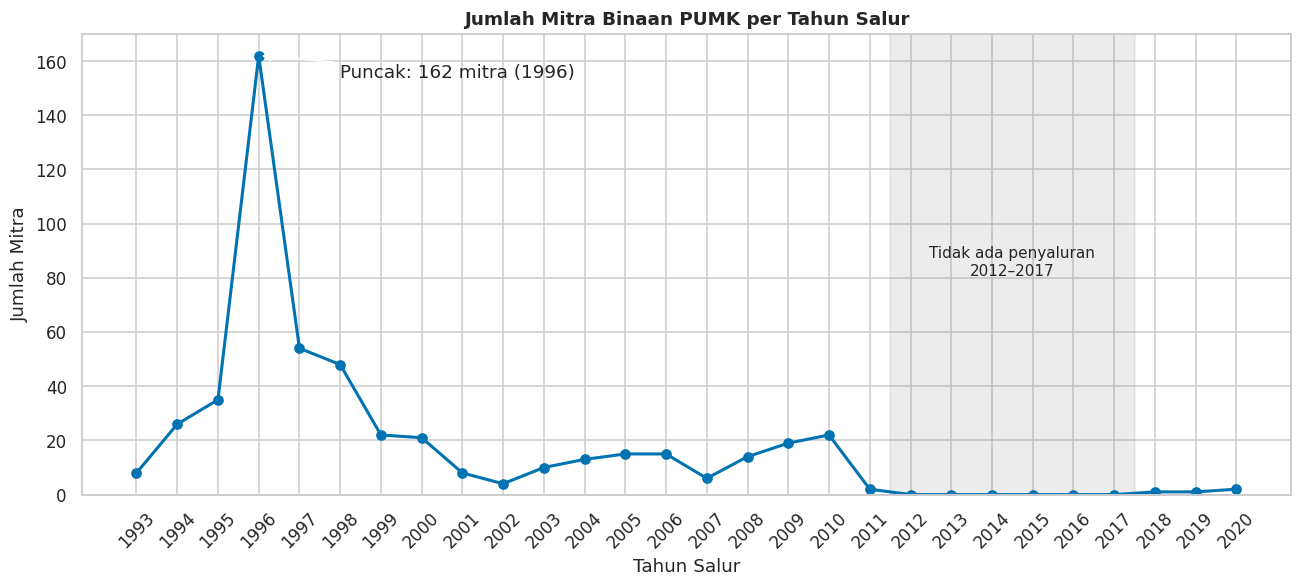

In [16]:
# ============================================================
# C2. GRAFIK TREN JUMLAH MITRA PER TAHUN
# ============================================================

# Membuat kanvas grafik
fig, ax = plt.subplots(figsize=(12, 5.5))

# Garis jumlah mitra per tahun dengan penanda titik
ax.plot(trend_tahunan["TAHUN SALUR"], trend_tahunan["JUMLAH MITRA"], marker="o", linewidth=2)

# Memberi area abu-abu dan keterangan pada setiap rentang tanpa penyaluran
for awal, akhir in rentang_kosong:
    ax.axvspan(awal - 0.5, akhir + 0.5, color="grey", alpha=0.15)          # Area abu-abu
    ax.text((awal + akhir) / 2, trend_tahunan["JUMLAH MITRA"].max() * 0.5, # Posisi teks di tengah area
            f"Tidak ada penyaluran\n{awal}–{akhir}", ha="center", fontsize=10)

# Menandai tahun dengan jumlah mitra terbanyak
baris_puncak = trend_tahunan.loc[trend_tahunan["JUMLAH MITRA"].idxmax()]
ax.annotate(f"Puncak: {int(baris_puncak['JUMLAH MITRA'])} mitra ({int(baris_puncak['TAHUN SALUR'])})",
            xy=(baris_puncak["TAHUN SALUR"], baris_puncak["JUMLAH MITRA"]),  # Titik yang ditunjuk
            xytext=(baris_puncak["TAHUN SALUR"] + 2, baris_puncak["JUMLAH MITRA"] * 0.95),  # Posisi teks
            arrowprops=dict(arrowstyle="->"))

# Judul dan label sumbu
ax.set_title("Jumlah Mitra Binaan PUMK per Tahun Salur", fontweight="bold")
ax.set_xlabel("Tahun Salur")
ax.set_ylabel("Jumlah Mitra")
# Menampilkan semua tahun pada sumbu X
ax.set_xticks(tahun_lengkap)
ax.tick_params(axis="x", rotation=45)
# Sumbu Y dimulai dari 0
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

### C3. Ringkasan per periode 5 tahunan
**Tujuan:** membandingkan periode secara adil. Karena periode terakhir hanya 3 tahun, kolom **rata-rata per tahun** dipakai untuk perbandingan antarperiode.

**Cara membaca output:** kolom "PERSENTASE (%)" menunjukkan porsi mitra per periode dari total 508 mitra.

In [17]:
# ============================================================
# C3. RINGKASAN PER PERIODE 5 TAHUNAN
# ============================================================

# Jumlah mitra per periode; reindex menjamin urutan periode dan periode kosong tetap tampil
ringkasan_periode = (
    df_clean["PERIODE SALUR"].astype(str).value_counts()
    .reindex(LABEL_PERIODE, fill_value=0)
    .rename_axis("PERIODE SALUR")
    .to_frame("JUMLAH MITRA")
)

# Persentase terhadap total mitra
ringkasan_periode["PERSENTASE (%)"] = (ringkasan_periode["JUMLAH MITRA"] / len(df_clean) * 100).round(2)

# Panjang tiap periode (dalam tahun), dihitung dari batas periode
ringkasan_periode["JUMLAH TAHUN"] = [akhir - awal for awal, akhir in zip(BATAS_PERIODE[:-1], BATAS_PERIODE[1:])]

# Rata-rata mitra per tahun agar periode dengan panjang berbeda dapat dibandingkan
ringkasan_periode["RATA-RATA PER TAHUN"] = (
    ringkasan_periode["JUMLAH MITRA"] / ringkasan_periode["JUMLAH TAHUN"]
).round(1)

# Validasi total
assert ringkasan_periode["JUMLAH MITRA"].sum() == len(df_clean)

display(ringkasan_periode)

,JUMLAH MITRA,PERSENTASE (%),JUMLAH TAHUN,RATA-RATA PER TAHUN
PERIODE SALUR,,,,
1993–1997,285,56.10,5,57.0
1998–2002,103,20.28,5,20.6
2003–2007,59,11.61,5,11.8
2008–2012,57,11.22,5,11.4
2013–2017,0,0.00,5,0.0
2018–2020,4,0.79,3,1.3


### C4. Grafik rata-rata mitra per tahun pada setiap periode
**Tujuan:** menampilkan tren jangka panjang dalam bentuk yang lebih stabil daripada data tahunan.

**Mengapa rata-rata per tahun, bukan jumlah?** Periode 2018–2020 hanya 3 tahun. Membandingkan jumlahnya langsung dengan periode 5 tahun akan tidak adil.

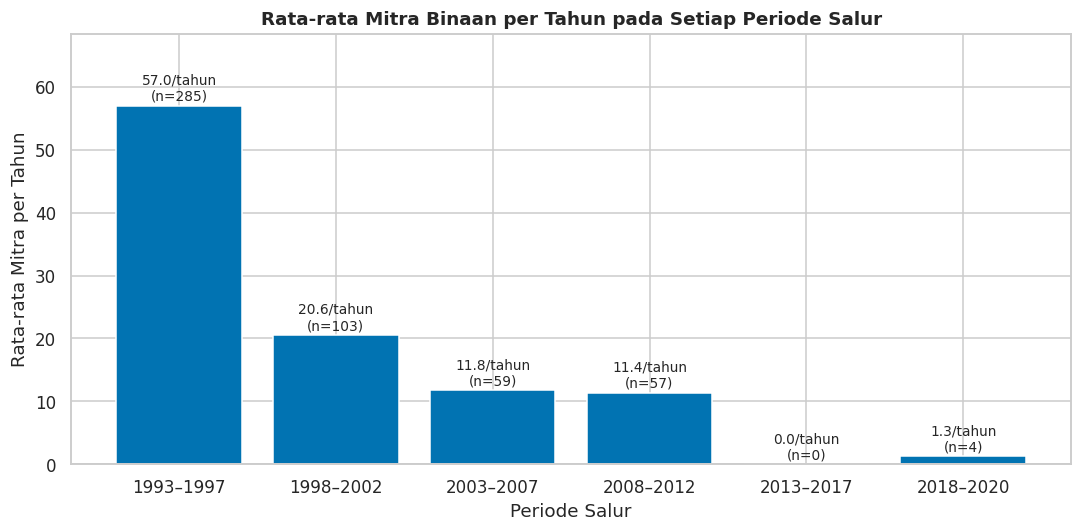

In [18]:
# ============================================================
# C4. GRAFIK RATA-RATA MITRA PER TAHUN PER PERIODE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Batang rata-rata mitra per tahun untuk setiap periode
batang = ax.bar(ringkasan_periode.index.astype(str), ringkasan_periode["RATA-RATA PER TAHUN"])

# Label di atas batang: rata-rata per tahun dan total mitra (n)
for kotak, (rata, total) in zip(batang, ringkasan_periode[["RATA-RATA PER TAHUN", "JUMLAH MITRA"]].values):
    ax.text(kotak.get_x() + kotak.get_width() / 2,        # Posisi horizontal: tengah batang
            kotak.get_height() + 0.8,                     # Posisi vertikal: sedikit di atas batang
            f"{rata:.1f}/tahun\n(n={int(total)})",        # Isi label
            ha="center", fontsize=9)

ax.set_title("Rata-rata Mitra Binaan per Tahun pada Setiap Periode Salur", fontweight="bold")
ax.set_xlabel("Periode Salur")
ax.set_ylabel("Rata-rata Mitra per Tahun")
# Ruang tambahan di atas agar label tidak terpotong
ax.set_ylim(0, ringkasan_periode["RATA-RATA PER TAHUN"].max() * 1.2)

plt.tight_layout()
plt.show()

### C5. Fungsi bantu visualisasi distribusi & tahun
**Tujuan:** ada tiga variabel (sektor, lokasi, unit) yang divisualisasikan dengan cara yang sama. Karena itu dibuat dua fungsi agar kode tidak diulang dan formatnya konsisten:
1. `plot_distribusi()`: bar chart horizontal jumlah dan persentase mitra per kategori.
2. `heatmap_tahun()`: heatmap tahun × kategori. Sel bernilai 0 dibiarkan kosong agar pola mudah dibaca.

**Mengapa bar chart, bukan pie chart?** Mata manusia lebih akurat membandingkan panjang batang daripada sudut irisan, dan beberapa kategori berukuran < 1% tidak akan terbaca di pie chart.

In [19]:
# ============================================================
# C5. FUNGSI BANTU VISUALISASI
# ============================================================

def plot_distribusi(kolom, judul, label_kategori):
    """Bar chart horizontal: jumlah & persentase mitra per kategori, urut dari terbesar."""
    # Menghitung jumlah mitra per kategori, diurutkan menaik (terbesar tampil di atas)
    jumlah = df_clean[kolom].value_counts().sort_values(ascending=True)
    # Tinggi kanvas menyesuaikan jumlah kategori
    fig, ax = plt.subplots(figsize=(10, 0.55 * len(jumlah) + 1.5))
    # Batang horizontal; nama kategori diubah ke list teks biasa
    ax.barh(list(jumlah.index.astype(str)), jumlah.values)
    # Menulis jumlah dan persentase di ujung setiap batang
    for posisi, nilai in enumerate(jumlah.values):
        ax.text(nilai + 1, posisi, f"{nilai} ({nilai / len(df_clean) * 100:.1f}%)", va="center", fontsize=9)
    ax.set_title(judul, fontweight="bold")
    ax.set_xlabel("Jumlah Mitra")
    ax.set_ylabel(label_kategori)
    # Ruang tambahan di kanan untuk label
    ax.set_xlim(0, jumlah.max() * 1.2)
    plt.tight_layout()
    plt.show()
    # Mengembalikan tabel (urut menurun) untuk ditampilkan atau dipakai lagi
    return jumlah.sort_values(ascending=False).to_frame("JUMLAH MITRA")


def heatmap_tahun(kolom, judul, label_kategori):
    """Heatmap jumlah mitra per tahun × kategori; sel bernilai 0 tidak diberi angka."""
    # Tabel silang tahun × kategori
    tabel = pd.crosstab(df_clean["TAHUN SALUR"].astype(int), df_clean[kolom].astype(str))
    # Menambahkan tahun kosong sebagai baris nol (hanya jika terkonfirmasi)
    if TAHUN_KOSONG_TERKONFIRMASI_NOL:
        tabel = tabel.reindex(tahun_lengkap, fill_value=0)
    # Anotasi: angka untuk sel > 0, kosong untuk sel 0
    anotasi = tabel.astype(str).where(tabel > 0, "")
    fig, ax = plt.subplots(figsize=(max(8, 1.2 * tabel.shape[1] + 2), 10))
    sns.heatmap(tabel, annot=anotasi, fmt="", cmap="Blues", linewidths=0.5,
                cbar_kws={"label": "Jumlah mitra"}, ax=ax)
    ax.set_title(judul, fontweight="bold")
    ax.set_xlabel(label_kategori)
    ax.set_ylabel("Tahun Salur")
    # Label kategori dimiringkan agar tidak bertumpuk
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()
    return tabel

print("Fungsi plot_distribusi() dan heatmap_tahun() siap digunakan.")

Fungsi plot_distribusi() dan heatmap_tahun() siap digunakan.


### C6. Distribusi mitra berdasarkan sektor usaha
**Pertanyaan yang dijawab:** sektor apa yang paling banyak dibina selama seluruh periode?

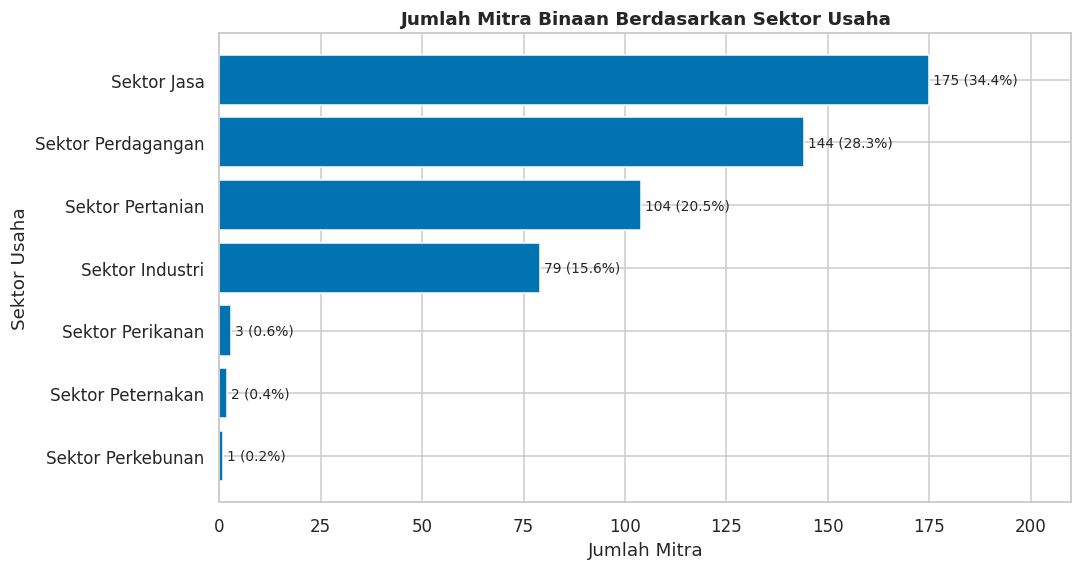

,JUMLAH MITRA
SEKTOR_ANALISIS,
Sektor Jasa,175
Sektor Perdagangan,144
Sektor Pertanian,104
Sektor Industri,79
Sektor Perikanan,3
Sektor Peternakan,2
Sektor Perkebunan,1


In [20]:
# ============================================================
# C6. DISTRIBUSI MITRA BERDASARKAN SEKTOR USAHA
# ============================================================

# Memanggil fungsi bantu untuk kolom sektor
distribusi_sektor = plot_distribusi("SEKTOR_ANALISIS", "Jumlah Mitra Binaan Berdasarkan Sektor Usaha", "Sektor Usaha")
display(distribusi_sektor)

### C7. Heatmap tahun × sektor
**Pertanyaan yang dijawab:** pada tahun berapa setiap sektor disalurkan? Apakah ada sektor yang hanya muncul di periode tertentu?

**Mengapa heatmap, bukan grafik garis per sektor?** Tujuh garis dengan lonjakan besar di satu tahun sulit dibaca. Heatmap menampilkan semua kombinasi tahun × sektor sekaligus.

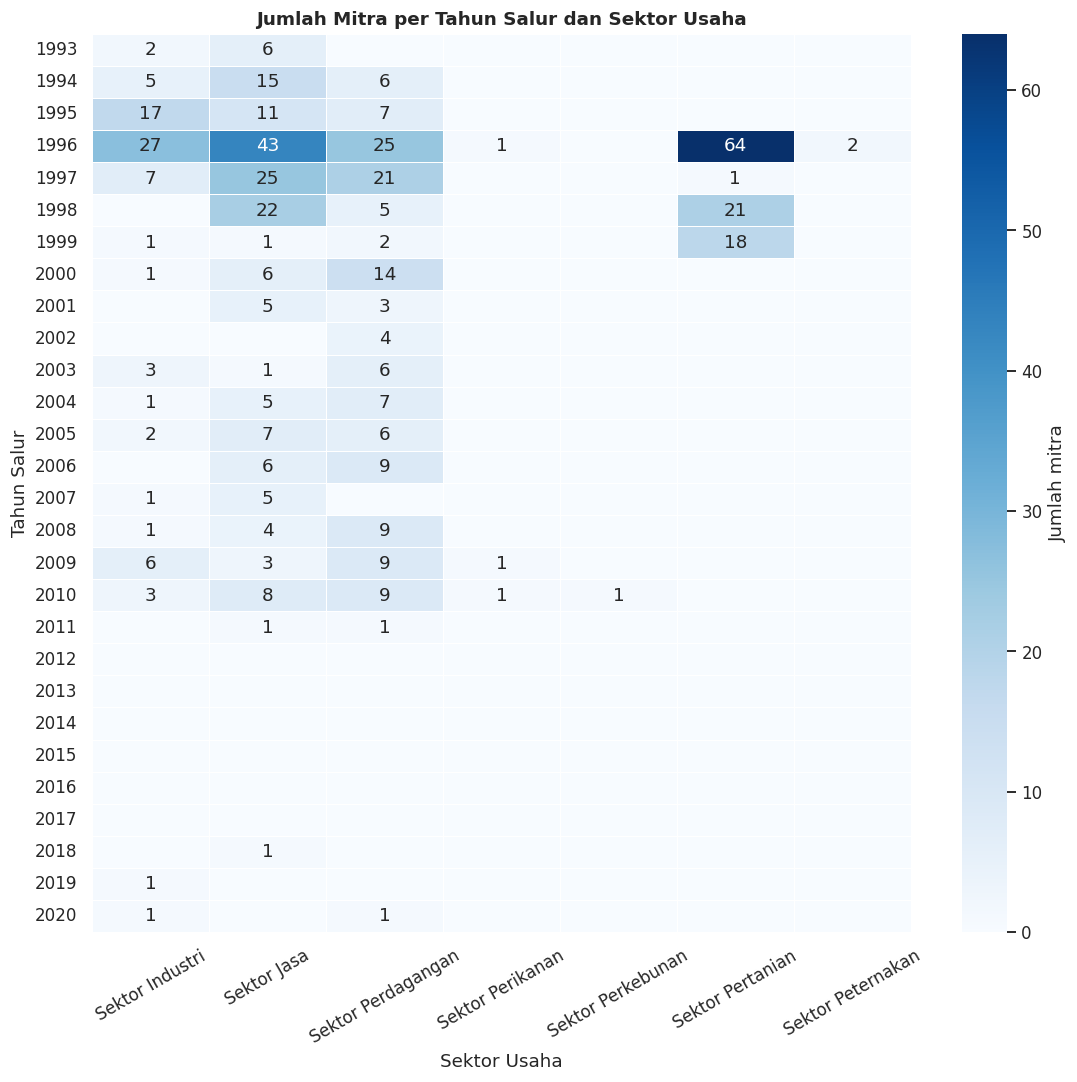

In [21]:
# ============================================================
# C7. HEATMAP TAHUN × SEKTOR
# ============================================================

# Memanggil fungsi bantu heatmap untuk kolom sektor
pivot_sektor = heatmap_tahun("SEKTOR_ANALISIS", "Jumlah Mitra per Tahun Salur dan Sektor Usaha", "Sektor Usaha")

### C8. Komposisi sektor per periode
**Pertanyaan yang dijawab:** apakah komposisi sektor berubah dari waktu ke waktu?

**Mengapa per periode, bukan per tahun?** Tahun dengan 1–2 mitra akan tampil sebagai batang 100% satu sektor, seolah-olah terjadi pergeseran besar. Periode tanpa penyaluran dikeluarkan dari grafik karena proporsinya tidak terdefinisi.

**Cara membaca:** label *n* di atas batang adalah jumlah mitra per periode. Komposisi periode dengan *n* sangat kecil (misalnya 2018–2020) **tidak boleh diinterpretasikan** sebagai pola.

SEKTOR_ANALISIS,Sektor Industri,Sektor Jasa,Sektor Perdagangan,Sektor Perikanan,Sektor Perkebunan,Sektor Pertanian,Sektor Peternakan
PERIODE SALUR,,,,,,,
1993–1997,20.35,35.09,20.70,0.35,0.00,22.81,0.7
1998–2002,1.94,33.01,27.18,0.00,0.00,37.86,0.0
2003–2007,11.86,40.68,47.46,0.00,0.00,0.00,0.0
2008–2012,17.54,28.07,49.12,3.51,1.75,0.00,0.0
2018–2020,50.00,25.00,25.00,0.00,0.00,0.00,0.0


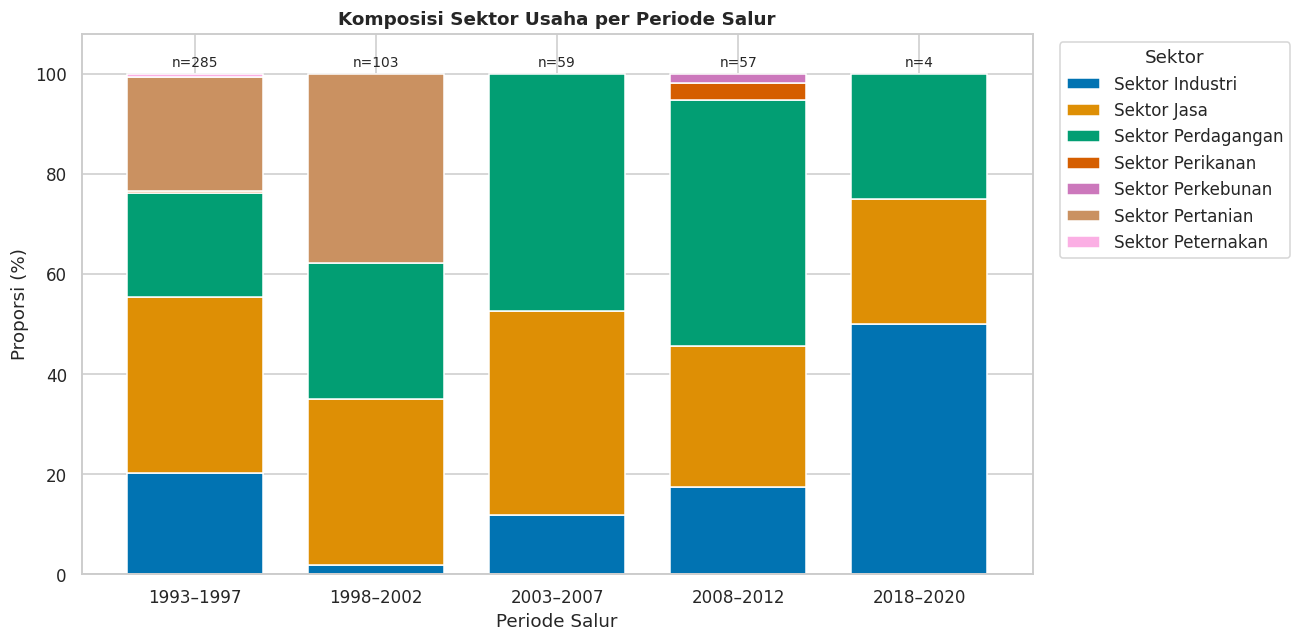

In [22]:
# ============================================================
# C8. KOMPOSISI SEKTOR PER PERIODE
# ============================================================

# Tabel silang periode × sektor; reindex menjamin urutan periode
pivot_sektor_periode = (
    pd.crosstab(df_clean["PERIODE SALUR"].astype(str), df_clean["SEKTOR_ANALISIS"].astype(str))
    .reindex(LABEL_PERIODE, fill_value=0)
)
# Mengeluarkan periode tanpa penyaluran (proporsinya tidak terdefinisi)
pivot_sektor_periode = pivot_sektor_periode.loc[pivot_sektor_periode.sum(axis=1) > 0]

# Proporsi (%) setiap sektor dalam setiap periode
proporsi_sektor_periode = pivot_sektor_periode.div(pivot_sektor_periode.sum(axis=1), axis=0) * 100
display(proporsi_sektor_periode.round(2))

# Grafik batang bertumpuk 100%
ax = proporsi_sektor_periode.plot(kind="bar", stacked=True, figsize=(12, 6), width=0.75)
# Menulis jumlah mitra (n) di atas setiap batang
for posisi, total in enumerate(pivot_sektor_periode.sum(axis=1)):
    ax.text(posisi, 101.5, f"n={total}", ha="center", fontsize=9)
ax.set_ylim(0, 108)
ax.set_title("Komposisi Sektor Usaha per Periode Salur", fontweight="bold")
ax.set_xlabel("Periode Salur")
ax.set_ylabel("Proporsi (%)")
ax.tick_params(axis="x", rotation=0)
# Legenda di luar area grafik
ax.legend(title="Sektor", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### C9. Distribusi mitra berdasarkan lokasi
**Pertanyaan yang dijawab:** kabupaten/kota mana yang memiliki mitra binaan terbanyak?

**Catatan:** BIMA (kabupaten) dan KOTA BIMA adalah wilayah administratif yang berbeda, sehingga tidak digabung.

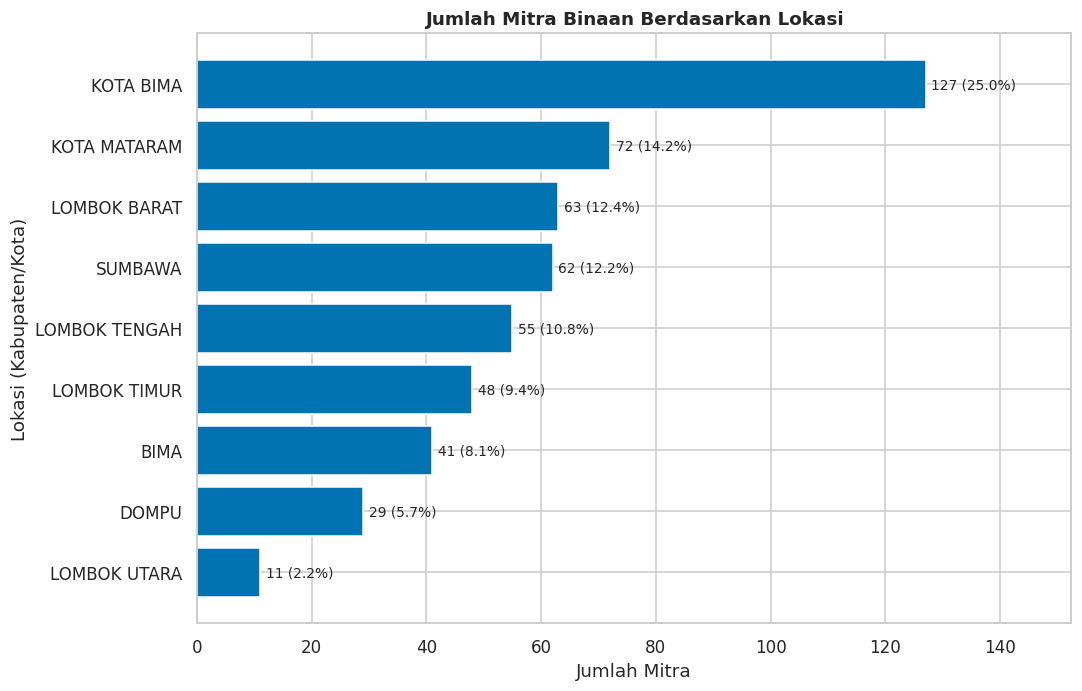

,JUMLAH MITRA
LOKASI_ANALISIS,
KOTA BIMA,127
KOTA MATARAM,72
LOMBOK BARAT,63
SUMBAWA,62
LOMBOK TENGAH,55
LOMBOK TIMUR,48
BIMA,41
DOMPU,29
LOMBOK UTARA,11


In [23]:
# ============================================================
# C9. DISTRIBUSI MITRA BERDASARKAN LOKASI
# ============================================================

distribusi_lokasi = plot_distribusi("LOKASI_ANALISIS", "Jumlah Mitra Binaan Berdasarkan Lokasi", "Lokasi (Kabupaten/Kota)")
display(distribusi_lokasi)

### C10. Heatmap tahun × lokasi
**Pertanyaan yang dijawab:** di wilayah mana penyaluran terjadi pada setiap tahun?

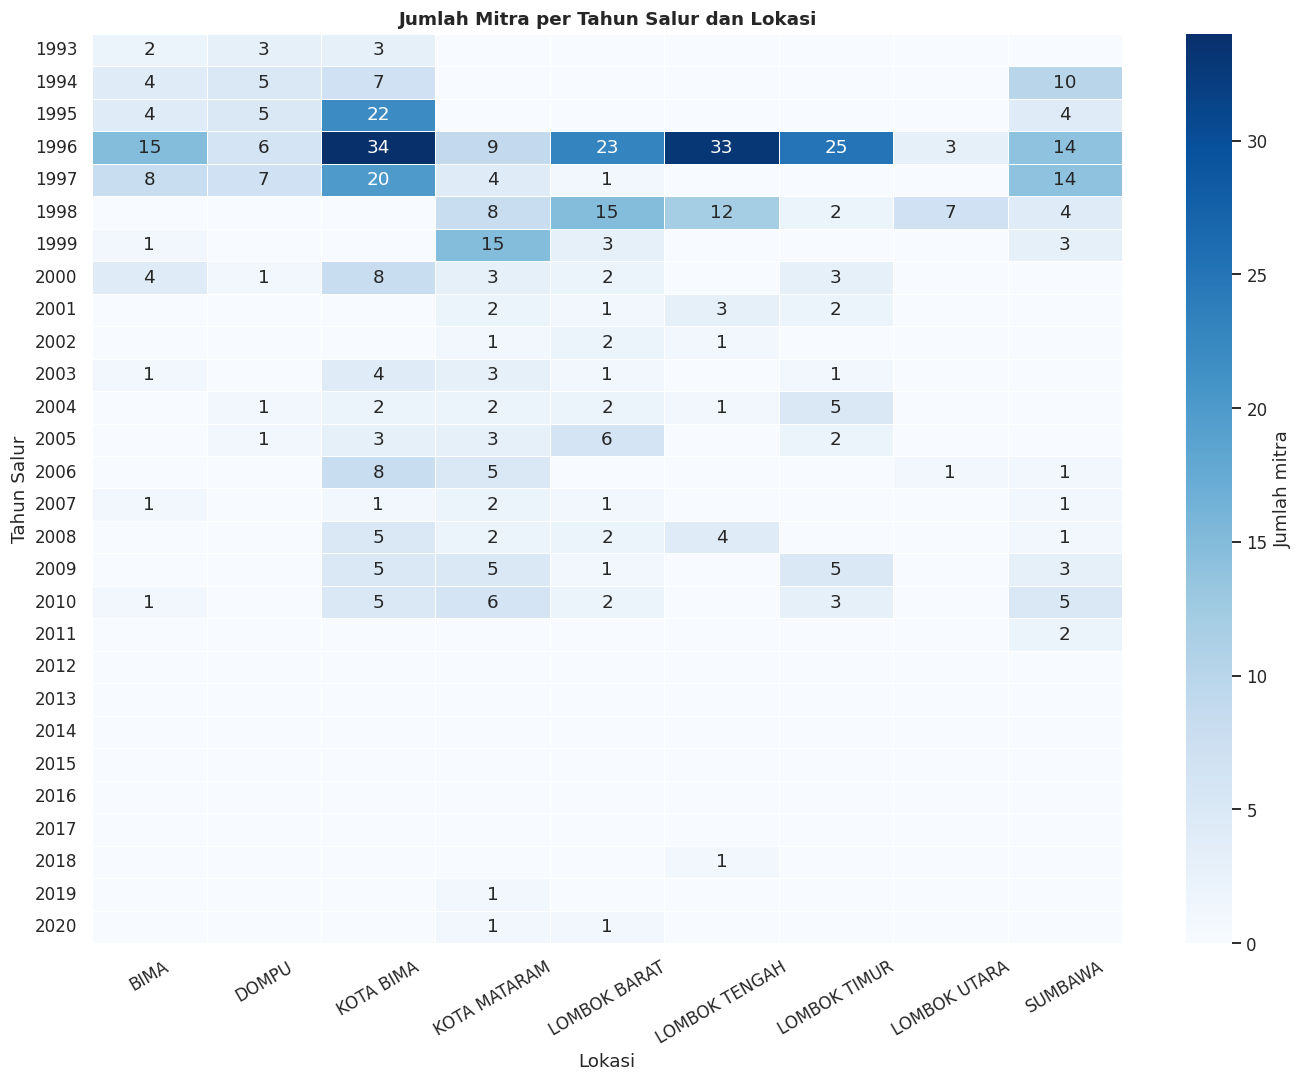

In [24]:
# ============================================================
# C10. HEATMAP TAHUN × LOKASI
# ============================================================

pivot_lokasi = heatmap_tahun("LOKASI_ANALISIS", "Jumlah Mitra per Tahun Salur dan Lokasi", "Lokasi")

### C11. Distribusi mitra berdasarkan unit pelaksana
**Pertanyaan yang dijawab:** unit pelaksana mana yang membina mitra terbanyak?

**Catatan istilah:**
- UP3 adalah unit pelaksana pelayanan pelanggan (berbasis wilayah).
- UP2B, UP2D, dan UPT umumnya bukan unit wilayah pelayanan (pengatur beban, pengatur distribusi, transmisi).

Karena itu, UNIT di data ini lebih tepat dibaca sebagai **unit pembina**, bukan wilayah. Konfirmasikan istilah ini ke pembimbing lapangan sebelum dipakai di laporan.

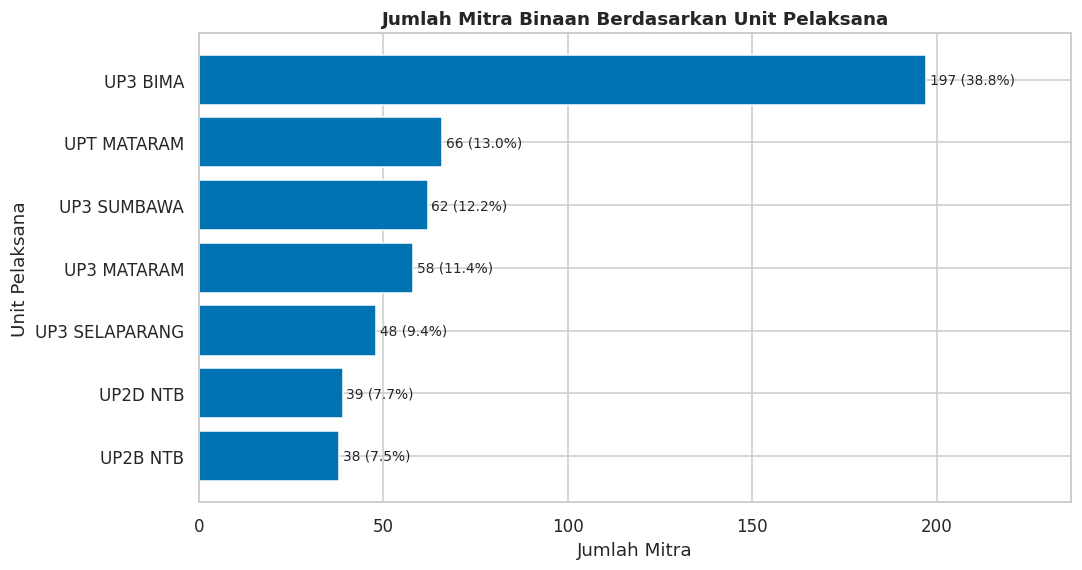

,JUMLAH MITRA
UNIT_ANALISIS,
UP3 BIMA,197
UPT MATARAM,66
UP3 SUMBAWA,62
UP3 MATARAM,58
UP3 SELAPARANG,48
UP2D NTB,39
UP2B NTB,38


In [25]:
# ============================================================
# C11. DISTRIBUSI MITRA BERDASARKAN UNIT PELAKSANA
# ============================================================

distribusi_unit = plot_distribusi("UNIT_ANALISIS", "Jumlah Mitra Binaan Berdasarkan Unit Pelaksana", "Unit Pelaksana")
display(distribusi_unit)

### C12. Heatmap tahun × unit pelaksana
**Pertanyaan yang dijawab:** unit mana yang aktif menyalurkan pada setiap tahun?

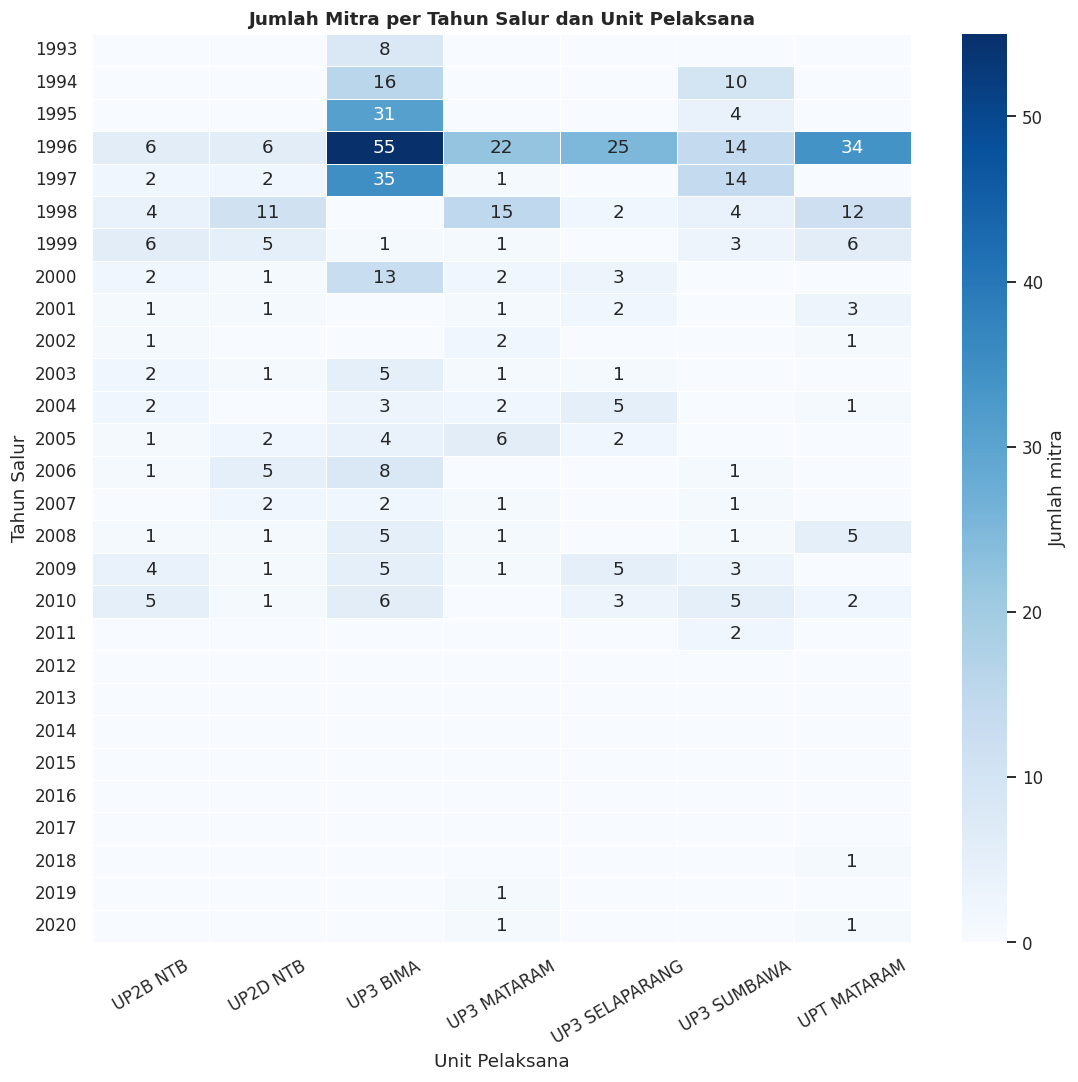

In [26]:
# ============================================================
# C12. HEATMAP TAHUN × UNIT PELAKSANA
# ============================================================

pivot_unit = heatmap_tahun("UNIT_ANALISIS", "Jumlah Mitra per Tahun Salur dan Unit Pelaksana", "Unit Pelaksana")

### C13. Ringkasan angka kunci analisis tren
**Tujuan:** merangkum temuan tren **langsung dari data**. Angka di sini boleh dikutip ke laporan.

**Catatan:** jika ada beberapa tahun dengan nilai yang sama (seri), semuanya ditampilkan, tidak hanya tahun pertama.

In [27]:
# ============================================================
# C13. RINGKASAN ANGKA KUNCI ANALISIS TREN
# ============================================================

# Hanya tahun yang memiliki penyaluran
tahun_berdata = trend_tahunan[trend_tahunan["JUMLAH MITRA"] > 0]

# Semua tahun dengan jumlah terbanyak (menangani kemungkinan seri)
tahun_puncak = tahun_berdata.loc[tahun_berdata["JUMLAH MITRA"] == tahun_berdata["JUMLAH MITRA"].max(), "TAHUN SALUR"].tolist()
# Semua tahun dengan jumlah paling sedikit (di antara tahun yang berdata)
tahun_terendah = tahun_berdata.loc[tahun_berdata["JUMLAH MITRA"] == tahun_berdata["JUMLAH MITRA"].min(), "TAHUN SALUR"].tolist()

# Periode dengan porsi mitra terbesar
periode_terbesar = ringkasan_periode["JUMLAH MITRA"].idxmax()

print("RINGKASAN ANALISIS TREN")
print("=" * 60)
print(f"Total mitra                   : {len(df_clean)}")
print(f"Rentang tahun salur           : {tahun_awal}–{tahun_akhir} ({len(tahun_lengkap)} tahun)")
print(f"Tahun dengan penyaluran       : {len(tahun_berdata)} tahun")
print(f"Tahun tanpa penyaluran        : {tahun_kosong}")
print(f"Tahun puncak                  : {tahun_puncak} ({tahun_berdata['JUMLAH MITRA'].max()} mitra, "
      f"{tahun_berdata['JUMLAH MITRA'].max() / len(df_clean) * 100:.1f}% dari total)")
print(f"Tahun terendah (berdata)      : {tahun_terendah} ({tahun_berdata['JUMLAH MITRA'].min()} mitra)")
print(f"Periode dengan mitra terbanyak: {periode_terbesar} "
      f"({ringkasan_periode.loc[periode_terbesar, 'PERSENTASE (%)']:.2f}% dari total)")
print(f"Sektor terbesar               : {distribusi_sektor.index[0]} ({distribusi_sektor.iloc[0, 0]} mitra)")
print(f"Lokasi terbesar               : {distribusi_lokasi.index[0]} ({distribusi_lokasi.iloc[0, 0]} mitra)")
print(f"Unit terbesar                 : {distribusi_unit.index[0]} ({distribusi_unit.iloc[0, 0]} mitra)")

RINGKASAN ANALISIS TREN
Total mitra                   : 508
Rentang tahun salur           : 1993–2020 (28 tahun)
Tahun dengan penyaluran       : 22 tahun
Tahun tanpa penyaluran        : [2012, 2013, 2014, 2015, 2016, 2017]
Tahun puncak                  : [1996] (162 mitra, 31.9% dari total)
Tahun terendah (berdata)      : [2018, 2019] (1 mitra)
Periode dengan mitra terbanyak: 1993–1997 (56.10% dari total)
Sektor terbesar               : Sektor Jasa (175 mitra)
Lokasi terbesar               : KOTA BIMA (127 mitra)
Unit terbesar                 : UP3 BIMA (197 mitra)


---
# BAGIAN D — PEMERIKSAAN FITUR CLUSTERING (SEBELUM PEMODELAN)

Bagian ini dijalankan **sebelum** K-Modes. Tujuannya memahami hubungan antar-fitur, karena hubungan itu menentukan cara hasil cluster harus dibaca.

### D1. Tabel silang lokasi × unit pelaksana
**Tujuan:** melihat seberapa erat lokasi dan unit saling terkait.

**Cara membaca:**
- Jika hampir setiap lokasi hanya muncul di satu unit, kedua variabel membawa informasi yang mirip (sama-sama informasi **wilayah**).
- Kolom `% UNIT DOMINAN` menunjukkan porsi mitra di lokasi tersebut yang dibina oleh unit yang paling sering.

,UNIT DOMINAN,% UNIT DOMINAN,JUMLAH MITRA
LOKASI_ANALISIS,,,
KOTA BIMA,UP3 BIMA,100.0,127
KOTA MATARAM,UP2B NTB,47.2,72
LOMBOK BARAT,UP3 MATARAM,88.9,63
SUMBAWA,UP3 SUMBAWA,100.0,62
LOMBOK TENGAH,UPT MATARAM,100.0,55
LOMBOK TIMUR,UP3 SELAPARANG,100.0,48
BIMA,UP3 BIMA,100.0,41
DOMPU,UP3 BIMA,100.0,29
LOMBOK UTARA,UP2D NTB,63.6,11


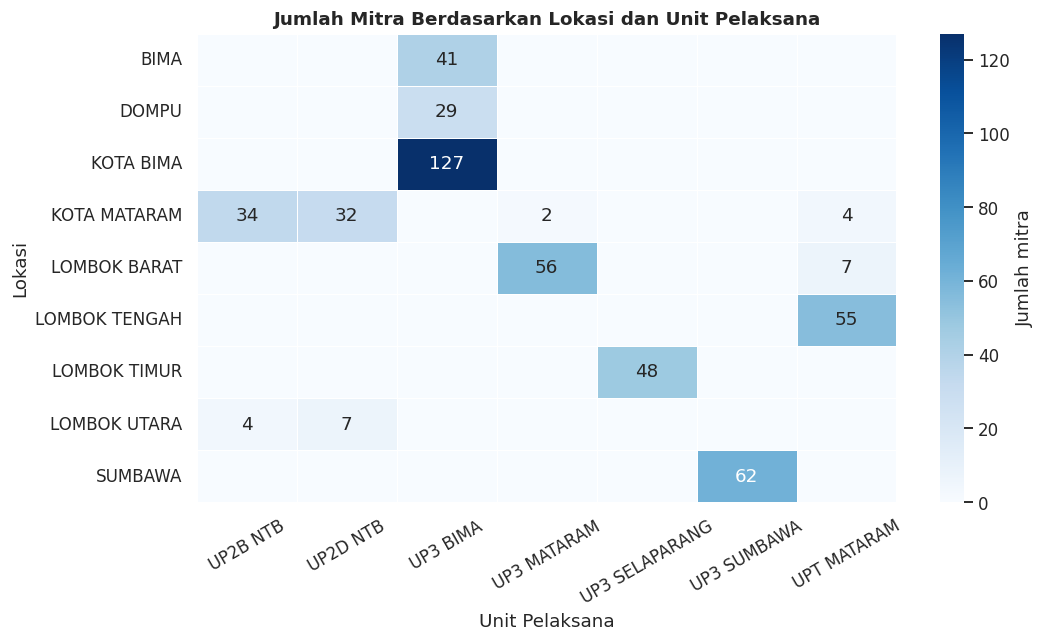

In [28]:
# ============================================================
# D1. TABEL SILANG LOKASI × UNIT PELAKSANA
# ============================================================

# Jumlah mitra untuk setiap kombinasi lokasi dan unit
tabel_lokasi_unit = pd.crosstab(df_clean["LOKASI_ANALISIS"].astype(str), df_clean["UNIT_ANALISIS"].astype(str))

# Persentase mitra yang berada di unit paling sering, untuk setiap lokasi
ringkas_lokasi_unit = pd.DataFrame({
    "UNIT DOMINAN": tabel_lokasi_unit.idxmax(axis=1),                                                  # Unit terbanyak per lokasi
    "% UNIT DOMINAN": (tabel_lokasi_unit.max(axis=1) / tabel_lokasi_unit.sum(axis=1) * 100).round(1),  # Porsinya
    "JUMLAH MITRA": tabel_lokasi_unit.sum(axis=1),                                                     # Total mitra per lokasi
})
display(ringkas_lokasi_unit.sort_values("JUMLAH MITRA", ascending=False))

# Heatmap jumlah mitra (sel 0 dikosongkan agar pola terlihat)
anotasi = tabel_lokasi_unit.astype(str).where(tabel_lokasi_unit > 0, "")
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(tabel_lokasi_unit, annot=anotasi, fmt="", cmap="Blues", linewidths=0.5,
            cbar_kws={"label": "Jumlah mitra"}, ax=ax)
ax.set_title("Jumlah Mitra Berdasarkan Lokasi dan Unit Pelaksana", fontweight="bold")
ax.set_xlabel("Unit Pelaksana")
ax.set_ylabel("Lokasi")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### D2. Asosiasi antarvariabel: Cramér's V terkoreksi
**Tujuan:** mengukur kekuatan hubungan antar-variabel kategorikal, dengan skala 0 (tidak berhubungan) sampai 1 (salah satu variabel sepenuhnya menentukan yang lain).

**Rumus:**

$$V = \sqrt{\frac{\chi^2 / n}{\min(r-1,\; c-1)}}$$

Dengan $r$ dan $c$ adalah jumlah kategori baris dan kolom. Versi **terkoreksi bias** (Bergsma, 2013) dipakai karena jumlah kategori banyak dan banyak sel berisi sedikit data; V biasa cenderung terlalu tinggi pada kondisi ini.

**Catatan penting:**
- Banyak sel memiliki frekuensi harapan < 5, sehingga **p-value chi-square tidak andal**.
- Karena itu V dipakai sebagai **ukuran deskriptif** kekuatan hubungan, bukan uji signifikansi.
- PERIODE SALUR ikut diukur untuk mengetahui apakah pola tahun pada profil cluster nantinya "terbawa" oleh fitur clustering.

,Variabel 1,Variabel 2,V,V terkoreksi,% sel expected < 5
0,LOKASI_ANALISIS,UNIT_ANALISIS,0.8801,0.8763,41.3
1,SEKTOR_ANALISIS,UNIT_ANALISIS,0.3158,0.2982,42.9
2,SEKTOR_ANALISIS,LOKASI_ANALISIS,0.3121,0.2874,50.8
3,UNIT_ANALISIS,PERIODE SALUR,0.2548,0.2313,31.4
4,LOKASI_ANALISIS,PERIODE SALUR,0.2584,0.2267,35.6
5,SEKTOR_ANALISIS,PERIODE SALUR,0.2256,0.1985,54.3


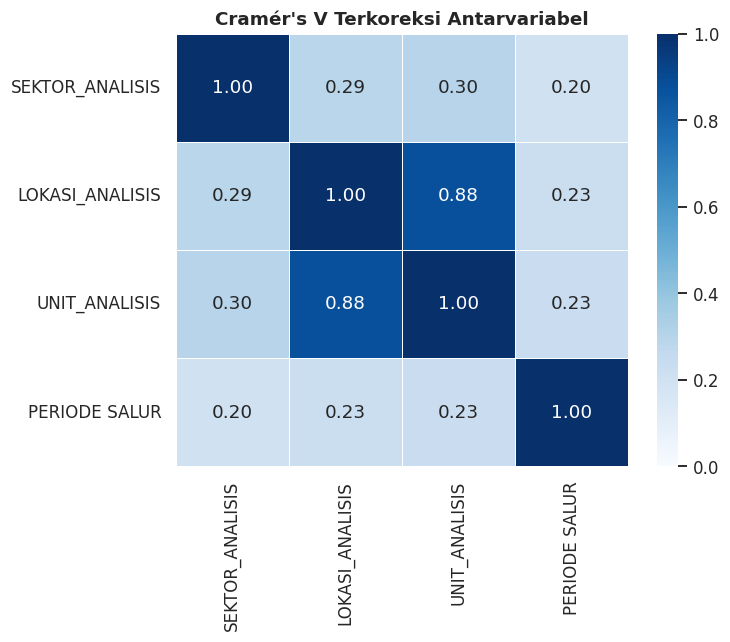

In [29]:
# ============================================================
# D2. CRAMÉR'S V TERKOREKSI UNTUK SEMUA PASANGAN VARIABEL
# ============================================================

def cramers_v(x, y, koreksi_bias=True):
    """Cramér's V antara dua variabel kategorikal; koreksi bias mengikuti Bergsma (2013)."""
    # Tabel silang; diubah ke teks agar hanya kategori yang benar-benar muncul yang dihitung
    tabel = pd.crosstab(x.astype(str), y.astype(str))
    # Statistik chi-square tanpa koreksi Yates
    chi2 = chi2_contingency(tabel, correction=False)[0]
    # Total pengamatan
    n = tabel.to_numpy().sum()
    # Jumlah kategori baris (r) dan kolom (c)
    r, c = tabel.shape
    # Phi kuadrat
    phi2 = chi2 / n
    # Versi tanpa koreksi
    if not koreksi_bias:
        return np.sqrt(phi2 / min(r - 1, c - 1))
    # Koreksi bias Bergsma: phi2, r, dan c dikoreksi
    phi2_kor = max(0, phi2 - (r - 1) * (c - 1) / (n - 1))
    r_kor = r - (r - 1) ** 2 / (n - 1)
    c_kor = c - (c - 1) ** 2 / (n - 1)
    return np.sqrt(phi2_kor / min(r_kor - 1, c_kor - 1))

# Variabel yang diukur: 3 fitur clustering + periode (variabel profiling)
variabel_asosiasi = FITUR_KMODES + ["PERIODE SALUR"]

# Wadah hasil per pasangan
hasil_v = []
# Matriks simetris untuk heatmap (diagonal = 1)
matriks_v = pd.DataFrame(1.0, index=variabel_asosiasi, columns=variabel_asosiasi)

# Menghitung V untuk setiap pasangan variabel
for var_1, var_2 in combinations(variabel_asosiasi, 2):
    # Tabel silang pasangan ini (untuk menghitung porsi sel ber-expected < 5)
    tabel = pd.crosstab(df_clean[var_1].astype(str), df_clean[var_2].astype(str))
    # Frekuensi harapan dari uji chi-square
    expected = chi2_contingency(tabel, correction=False)[3]
    # V terkoreksi
    v_kor = cramers_v(df_clean[var_1], df_clean[var_2])
    # Simpan satu baris hasil
    hasil_v.append({
        "Variabel 1": var_1,
        "Variabel 2": var_2,
        "V": round(cramers_v(df_clean[var_1], df_clean[var_2], koreksi_bias=False), 4),
        "V terkoreksi": round(v_kor, 4),
        "% sel expected < 5": round((expected < 5).mean() * 100, 1),
    })
    # Isi matriks di dua posisi (simetris)
    matriks_v.loc[var_1, var_2] = v_kor
    matriks_v.loc[var_2, var_1] = v_kor

# Tabel hasil, diurutkan dari asosiasi terkuat
hasil_v_df = pd.DataFrame(hasil_v).sort_values("V terkoreksi", ascending=False).reset_index(drop=True)
display(hasil_v_df)

# Heatmap matriks V
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(matriks_v, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Cramér's V Terkoreksi Antarvariabel", fontweight="bold")
plt.tight_layout()
plt.show()

### D3. Konsekuensi asosiasi terhadap clustering
**Tujuan:** menjelaskan secara terbuka apa arti asosiasi kuat bagi hasil K-Modes.

**Konsep:** K-Modes memberi bobot sama pada setiap fitur; satu fitur yang berbeda menambah jarak 1. Jika LOKASI dan UNIT sangat terkait, dua mitra yang berbeda wilayah biasanya berbeda di **kedua** fitur sekaligus (jarak +2), sedangkan perbedaan sektor hanya menambah jarak 1. Akibatnya, **informasi wilayah berbobot kira-kira dua kali** dibanding sektor.

**Keputusan desain:** ketiga fitur tetap dipakai karena penelitian ini memang ingin mensegmentasi **karakteristik sektor dan wilayah pembinaan**. Konsekuensinya harus ditulis di laporan: *pembagian cluster terutama mengikuti wilayah/unit, dan sektor membedakan mitra di dalam wilayah yang sama*.

**Output yang diharapkan:**
- daftar pasangan fitur dengan V terkoreksi ≥ 0,70;
- persentase pasangan mitra yang berbeda lokasi **dan juga** berbeda unit (bukti empiris pembobotan ganda).

In [30]:
# ============================================================
# D3. KONSEKUENSI ASOSIASI TERHADAP CLUSTERING
# ============================================================

# Pasangan FITUR clustering dengan asosiasi sangat kuat
pasangan_kuat = hasil_v_df[
    hasil_v_df["Variabel 1"].isin(FITUR_KMODES)                       # Variabel 1 adalah fitur clustering
    & hasil_v_df["Variabel 2"].isin(FITUR_KMODES)                     # Variabel 2 juga fitur clustering
    & (hasil_v_df["V terkoreksi"] >= AMBANG_CRAMERS_V)                # Asosiasi melewati ambang
]
print(f"Pasangan fitur clustering dengan V terkoreksi ≥ {AMBANG_CRAMERS_V}:")
display(pasangan_kuat)

# --- Bukti empiris pembobotan ganda wilayah ---
# Kode angka kategori lokasi dan unit untuk perbandingan cepat
kode_lokasi = pd.Categorical(df_clean["LOKASI_ANALISIS"]).codes
kode_unit = pd.Categorical(df_clean["UNIT_ANALISIS"]).codes
# Matriks True/False: apakah dua mitra berbeda lokasi (508 × 508)
beda_lokasi = kode_lokasi[:, None] != kode_lokasi[None, :]
# Matriks True/False: apakah dua mitra berbeda unit
beda_unit = kode_unit[:, None] != kode_unit[None, :]
# Hanya pasangan unik (segitiga atas, tanpa diagonal)
segitiga_atas = np.triu(np.ones_like(beda_lokasi, dtype=bool), k=1)

# Dari semua pasangan yang berbeda lokasi, berapa persen juga berbeda unit
persen_ikut_beda = (beda_lokasi & beda_unit & segitiga_atas).sum() / (beda_lokasi & segitiga_atas).sum() * 100
print(f"\nDari pasangan mitra yang BERBEDA LOKASI, {persen_ikut_beda:.1f}% juga BERBEDA UNIT.")
print("Artinya perbedaan wilayah umumnya dihitung dua kali dalam jarak K-Modes (lokasi + unit).")

Pasangan fitur clustering dengan V terkoreksi ≥ 0.7:


,Variabel 1,Variabel 2,V,V terkoreksi,% sel expected < 5
0,LOKASI_ANALISIS,UNIT_ANALISIS,0.8801,0.8763,41.3



Dari pasangan mitra yang BERBEDA LOKASI, 89.9% juga BERBEDA UNIT.
Artinya perbedaan wilayah umumnya dihitung dua kali dalam jarak K-Modes (lokasi + unit).


### D4. Profil unik kombinasi fitur
**Tujuan:** menghitung berapa banyak **kombinasi berbeda** (sektor, lokasi, unit) yang benar-benar ada di data.

**Mengapa penting?**
1. Jumlah profil unik adalah **batas atas K**. Jika K sama dengan jumlah profil unik, setiap cluster berisi satu kombinasi persis; silhouette mendekati 1, tetapi itu bukan segmentasi.
2. Banyak mitra memiliki kombinasi yang identik. K-Modes dapat dijalankan pada **profil unik dengan bobot = jumlah mitra** tanpa mengubah hasil (dibuktikan di E3), dan prosesnya jauh lebih cepat.

**Cara membaca:** kolom `KUMULATIF (%)` menunjukkan porsi mitra yang tercakup oleh *n* kombinasi terbesar.

In [31]:
# ============================================================
# D4. PROFIL UNIK KOMBINASI FITUR
# ============================================================

# Mengelompokkan mitra berdasarkan kombinasi 3 fitur; BOBOT = jumlah mitra dengan kombinasi itu
profil_unik = (
    df_clean.groupby(FITUR_KMODES)                    # Kelompokkan per kombinasi sektor-lokasi-unit
    .size()                                           # Hitung jumlah mitra per kombinasi
    .reset_index(name="BOBOT")                        # Jadikan DataFrame dengan kolom BOBOT
    .sort_values("BOBOT", ascending=False)            # Urutkan dari kombinasi terbanyak
    .reset_index(drop=True)
)
# Persentase kumulatif mitra yang tercakup
profil_unik["KUMULATIF (%)"] = (profil_unik["BOBOT"].cumsum() / len(df_clean) * 100).round(1)

# Jumlah kombinasi unik
n_profil_unik = len(profil_unik)

# Validasi: total bobot harus sama dengan jumlah mitra
assert profil_unik["BOBOT"].sum() == len(df_clean)

print("Jumlah kombinasi (sektor, lokasi, unit) yang muncul:", n_profil_unik)
print("Kombinasi dengan ≥ 5% mitra                        :",
      (profil_unik["BOBOT"] >= AMBANG_UKURAN_MIN * len(df_clean)).sum())
display(profil_unik)

Jumlah kombinasi (sektor, lokasi, unit) yang muncul: 45
Kombinasi dengan ≥ 5% mitra                        : 6


,SEKTOR_ANALISIS,LOKASI_ANALISIS,UNIT_ANALISIS,BOBOT,KUMULATIF (%)
0,Sektor Perdagangan,KOTA BIMA,UP3 BIMA,54,10.6
1,Sektor Jasa,SUMBAWA,UP3 SUMBAWA,43,19.1
2,Sektor Jasa,KOTA BIMA,UP3 BIMA,37,26.4
3,Sektor Industri,KOTA BIMA,UP3 BIMA,35,33.3
4,Sektor Pertanian,LOMBOK BARAT,UP3 MATARAM,32,39.6
5,Sektor Pertanian,LOMBOK TENGAH,UPT MATARAM,30,45.5
6,Sektor Perdagangan,KOTA MATARAM,UP2B NTB,24,50.2
7,Sektor Jasa,KOTA MATARAM,UP2D NTB,24,54.9
8,Sektor Jasa,LOMBOK TIMUR,UP3 SELAPARANG,21,59.1
9,Sektor Industri,BIMA,UP3 BIMA,21,63.2


---
# BAGIAN E — K-MODES: PEMILIHAN K DAN MODEL FINAL

### E0. Konsep K-Modes dan kriteria evaluasi

**1. Jarak antarmitra (simple matching / Hamming), Huang (1998)**

$$d(X, Q) = \sum_{j=1}^{m} \delta(x_j, q_j), \qquad \delta(x_j,q_j)=\begin{cases}0 & x_j = q_j\\ 1 & x_j \neq q_j\end{cases}$$

Dengan $m = 3$ fitur, jarak hanya bernilai 0, 1, 2, atau 3, yaitu jumlah fitur yang berbeda.

**2. Modus cluster:** untuk setiap fitur, kategori yang paling sering muncul di antara anggota cluster. Modus inilah "pusat" cluster.

**3. Cost:**

$$\text{Cost} = \sum_{i=1}^{n} d\big(X_i,\; Q_{\text{cluster}(i)}\big)$$

Cost adalah **total ketidakcocokan** antara setiap mitra dan modus cluster-nya. Contoh: cost 225 berarti ada 225 nilai fitur yang berbeda dari modus cluster, dihitung dari seluruh mitra.

**4. Penugasan:** setiap mitra masuk ke modus terdekat. Jika jaraknya **sama** ke beberapa modus (seri), library `kmodes` memilih cluster dengan **nomor indeks terkecil**. Mitra seperti ini ditandai sebagai *periferal (seri)*, karena keanggotaannya ditentukan aturan teknis, bukan kemiripan.

**5. Parameter**

| Parameter | Nilai | Alasan |
|---|---|---|
| `init="Huang"` | Huang (1998) | Inisialisasi acak berbasis frekuensi kategori; standar dalam literatur K-Modes |
| `n_init` | 200 | K-Modes hanya menjamin optimum lokal. Dari 200 percobaan, diambil cost terendah |
| `random_state` | 20 seed | Bukan satu seed "beruntung": solusi harus muncul kembali di banyak seed |

**6. Kriteria pemilihan K**

| Kriteria | Mengukur | Kelemahan jika dipakai sendirian |
|---|---|---|
| **Silhouette (Hamming)** | Seberapa mirip mitra dengan cluster-nya dibanding cluster terdekat lain | Terus naik saat K mendekati jumlah profil unik (over-segmentation), dibuktikan di E4 |
| **Cost** | Total ketidakcocokan | Selalu turun saat K naik |
| **Ukuran cluster terkecil** | Kelayakan cluster untuk kebijakan | Tidak mengukur kualitas pemisahan |
| **ARI antar-seed** | Apakah partisi yang sama muncul kembali | Tidak mengukur kualitas pemisahan |
| **% inti / % seri** | Kemurnian & kejelasan keanggotaan | Bersifat diagnostik |

Karena setiap kriteria punya kelemahan, K dipilih dengan **kombinasi kriteria** (aturan di A2).

**7. Tentang K ganjil**

K ganjil **bukan syarat statistik** dalam clustering. Bilangan ganjil penting pada metode lain seperti KNN (agar voting tidak seri), tetapi tidak ada teori yang membuat K-Modes lebih baik dengan K ganjil. Di notebook ini K ganjil diterapkan sebagai **arahan pembimbing** (`HANYA_K_GANJIL`), dan E8 memeriksa apakah batasan ini mengubah keputusan.

### E1. Menyiapkan data untuk K-Modes
**Tujuan:** menyiapkan tiga bentuk data:
1. `X_kmodes`: 508 mitra × 3 fitur (teks), untuk menetapkan cluster setiap mitra.
2. `X_silhouette`: versi angka dari `X_kmodes`, untuk menghitung silhouette.
3. `profil_unik` (dari D4): kombinasi unik + bobot, untuk melatih K-Modes.

**Apakah mengubah kategori menjadi angka untuk silhouette bermasalah?** Tidak. Jarak Hamming hanya memeriksa **sama atau tidak sama**, jadi nilai angkanya tidak pernah dipakai sebagai besaran. Kode 0, 1, 2 hanya label. Ini berbeda dengan jarak Euclidean, yang akan salah jika dipakai pada kode kategori.

In [32]:
# ============================================================
# E1. MENYIAPKAN DATA UNTUK K-MODES
# ============================================================

# Matriks fitur teks (508 × 3) diambil dari daftar fitur eksplisit, bukan seluruh DataFrame
X_kmodes = df_clean[FITUR_KMODES].astype(str).to_numpy()

# Versi angka untuk silhouette: setiap kategori diberi kode (hanya untuk uji sama/tidak sama)
X_silhouette = np.column_stack([
    pd.Categorical(df_clean[kolom].astype(str)).codes for kolom in FITUR_KMODES
])

print("Ukuran X_kmodes     :", X_kmodes.shape)
print("Ukuran X_silhouette :", X_silhouette.shape)
print("Jumlah profil unik  :", n_profil_unik)
print("\nContoh 5 baris X_kmodes:")
print(X_kmodes[:5])

Ukuran X_kmodes     : (508, 3)
Ukuran X_silhouette : (508, 3)
Jumlah profil unik  : 45

Contoh 5 baris X_kmodes:
[['Sektor Industri' 'BIMA' 'UP3 BIMA']
 ['Sektor Industri' 'KOTA BIMA' 'UP3 BIMA']
 ['Sektor Industri' 'BIMA' 'UP3 BIMA']
 ['Sektor Industri' 'KOTA BIMA' 'UP3 BIMA']
 ['Sektor Industri' 'BIMA' 'UP3 BIMA']]


### E2. Fungsi bantu K-Modes
**Tujuan:** membuat tiga fungsi yang dipakai berulang:
1. `buat_profil(data)`: membentuk profil unik + bobot dari sekumpulan mitra.
2. `latih_kmodes(profil, k, seed, n_init)`: melatih K-Modes pada profil berbobot.
3. `jarak_ke_modus(model, X)`: jarak setiap mitra ke setiap modus, untuk menghitung % inti dan % seri.

**Catatan teknis:** `sample_weight` di `kmodes` harus berupa list angka Python biasa. Karena itu dipakai `.tolist()`.

In [33]:
# ============================================================
# E2. FUNGSI BANTU K-MODES
# ============================================================

def buat_profil(data):
    """Profil unik (kombinasi fitur) beserta BOBOT = jumlah mitra per kombinasi."""
    return data.groupby(FITUR_KMODES).size().reset_index(name="BOBOT")


def latih_kmodes(profil, k, seed, n_init):
    """Melatih K-Modes pada profil unik berbobot; fungsi cost identik dengan melatih pada semua mitra."""
    # Membuat objek model dengan parameter yang ditetapkan
    model = KModes(n_clusters=k, init="Huang", n_init=n_init, random_state=seed)
    # Melatih: setiap profil diberi bobot sebanyak jumlah mitranya
    model.fit(profil[FITUR_KMODES].astype(str).to_numpy(), sample_weight=profil["BOBOT"].tolist())
    return model


def jarak_ke_modus(model, X):
    """Matriks jarak (n_mitra × K): jumlah fitur yang berbeda antara setiap mitra dan setiap modus."""
    # matching_dissim(modus, x) menghitung jarak satu mitra x ke semua modus sekaligus
    return np.array([matching_dissim(model.cluster_centroids_, baris) for baris in X])

print("Fungsi buat_profil(), latih_kmodes(), dan jarak_ke_modus() siap digunakan.")

Fungsi buat_profil(), latih_kmodes(), dan jarak_ke_modus() siap digunakan.


### E3. Verifikasi: pelatihan pada profil berbobot setara dengan pelatihan pada 508 mitra
**Tujuan:** membuktikan bahwa jalan pintas di E2 tidak mengubah hasil.

**Logika:** cost yang dilaporkan model (dihitung pada profil × bobot) harus **sama persis** dengan cost yang dihitung ulang langsung pada 508 mitra.

**Output yang diharapkan:** kedua angka sama dan pesan "Verifikasi lolos".

In [34]:
# ============================================================
# E3. VERIFIKASI KESETARAAN PROFIL BERBOBOT
# ============================================================

# Melatih satu model contoh (K=5, seed pertama)
model_uji = latih_kmodes(profil_unik, k=5, seed=DAFTAR_SEED[0], n_init=N_INIT)

# Menetapkan cluster untuk 508 mitra (modus terdekat; seri → indeks terkecil)
label_uji = model_uji.predict(X_kmodes).astype(int)

# Menghitung ulang cost langsung pada 508 mitra: jarak setiap mitra ke modus cluster-nya
jarak_uji = jarak_ke_modus(model_uji, X_kmodes)
cost_508_mitra = jarak_uji[np.arange(len(X_kmodes)), label_uji].sum()

print("Cost dari model (profil berbobot) :", model_uji.cost_)
print("Cost dihitung ulang pada 508 mitra:", cost_508_mitra)

# Keduanya harus identik
assert np.isclose(model_uji.cost_, cost_508_mitra), "Cost berbeda: periksa profil/bobot"
print("Verifikasi lolos: hasil pada profil berbobot setara dengan 508 mitra.")

Cost dari model (profil berbobot) : 465.0
Cost dihitung ulang pada 508 mitra: 465
Verifikasi lolos: hasil pada profil berbobot setara dengan 508 mitra.


### E4. Penelusuran cepat seluruh K (2 sampai jumlah profil unik − 1)
**Tujuan:** menunjukkan secara empiris mengapa **silhouette tidak boleh dipakai sendirian**, sekaligus membenarkan batas `K_MAKS_EVALUASI`.

**Metode:** satu seed dengan `n_init=50` (penelusuran kasar, bukan untuk memilih K).

**Cara membaca grafik:**
- Kiri: silhouette cenderung terus naik mendekati 1 saat K mendekati jumlah profil unik. Kenaikan ini terjadi karena cluster makin kecil dan makin "murni", bukan karena segmentasi makin bermakna.
- Kanan: ukuran cluster terkecil turun drastis. Garis merah adalah batas 5%. Di atas `K_MAKS_EVALUASI`, cluster terkecil sudah jauh di bawah batas, sehingga K tersebut tidak mungkin lolos aturan.

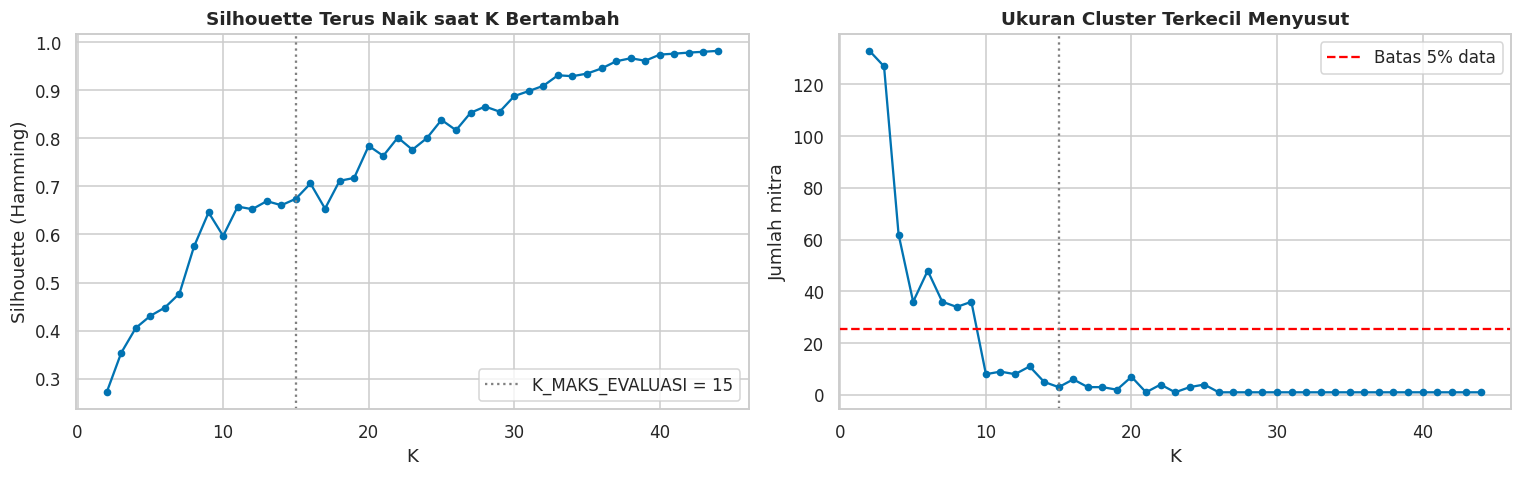

K > 15 yang cluster terkecilnya ≥ 5%: tidak ada


In [35]:
# ============================================================
# E4. PENELUSURAN CEPAT SELURUH K
# ============================================================

# Wadah hasil penelusuran
hasil_cepat = []

# K dari 2 sampai jumlah profil unik − 1 (K = jumlah profil unik berarti 1 profil per cluster)
for k in range(2, n_profil_unik):
    # Satu run cepat
    model_k = latih_kmodes(profil_unik, k, seed=DAFTAR_SEED[0], n_init=50)
    # Label untuk 508 mitra
    label_k = model_k.predict(X_kmodes).astype(int)
    # Simpan K, silhouette, dan ukuran cluster terkecil
    hasil_cepat.append({
        "K": k,
        "SILHOUETTE": silhouette_score(X_silhouette, label_k, metric="hamming"),
        "UKURAN_MIN": np.bincount(label_k, minlength=k).min(),
    })

# Ubah ke DataFrame
penelusuran_cepat = pd.DataFrame(hasil_cepat).set_index("K")

# Dua grafik berdampingan
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
# Kiri: silhouette terhadap K
axes[0].plot(penelusuran_cepat.index, penelusuran_cepat["SILHOUETTE"], marker="o", markersize=4)
axes[0].axvline(K_MAKS_EVALUASI, color="grey", linestyle=":", label=f"K_MAKS_EVALUASI = {K_MAKS_EVALUASI}")
axes[0].set_title("Silhouette Terus Naik saat K Bertambah", fontweight="bold")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Silhouette (Hamming)")
axes[0].legend()
# Kanan: ukuran cluster terkecil terhadap K
axes[1].plot(penelusuran_cepat.index, penelusuran_cepat["UKURAN_MIN"], marker="o", markersize=4)
axes[1].axhline(AMBANG_UKURAN_MIN * len(df_clean), color="red", linestyle="--",
                label=f"Batas {AMBANG_UKURAN_MIN:.0%} data")
axes[1].axvline(K_MAKS_EVALUASI, color="grey", linestyle=":")
axes[1].set_title("Ukuran Cluster Terkecil Menyusut", fontweight="bold")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Jumlah mitra")
axes[1].legend()
plt.tight_layout()
plt.show()

# K di atas batas evaluasi yang cluster terkecilnya masih memenuhi 5% (harapannya kosong)
lolos_di_atas_batas = penelusuran_cepat.loc[
    (penelusuran_cepat.index > K_MAKS_EVALUASI)
    & (penelusuran_cepat["UKURAN_MIN"] >= AMBANG_UKURAN_MIN * len(df_clean))
]
print(f"K > {K_MAKS_EVALUASI} yang cluster terkecilnya ≥ {AMBANG_UKURAN_MIN:.0%}:",
      lolos_di_atas_batas.index.tolist() or "tidak ada")

### E5. Evaluasi lengkap K = 2 sampai `K_MAKS_EVALUASI`
**Tujuan:** menghitung semua kriteria untuk setiap K.

**Proses untuk setiap K:**
1. Latih K-Modes dengan 20 seed berbeda (masing-masing `n_init=200`).
2. Ambil solusi dengan **cost terendah** sebagai solusi terbaik untuk K tersebut.
3. Hitung:
   - **SEED_MENCAPAI_COST_TERBAIK**: berapa persen seed yang menemukan cost terbaik. Jika rendah, solusinya sulit ditemukan.
   - **ARI_RATA2 / ARI_MIN**: kemiripan partisi setiap seed dengan solusi terbaik (1 = identik).
   - **SILHOUETTE**, **UKURAN_MIN**, **% INTI**, **% SERI**.

**Catatan waktu:** sel ini membutuhkan sekitar 3–5 menit di Colab. Progres dicetak per K.

In [36]:
# ============================================================
# E5. EVALUASI LENGKAP K = 2 .. K_MAKS_EVALUASI
# ============================================================

# Wadah hasil evaluasi, model terbaik, dan label terbaik per K
hasil_evaluasi = []
model_terbaik = {}
label_terbaik = {}

for k in range(2, K_MAKS_EVALUASI + 1):
    # Wadah hasil semua seed untuk K ini
    daftar_model, daftar_label, daftar_cost = [], [], []

    # Melatih K-Modes untuk setiap seed
    for seed in DAFTAR_SEED:
        model = latih_kmodes(profil_unik, k, seed, N_INIT)          # Latih pada profil berbobot
        daftar_model.append(model)                                  # Simpan model
        daftar_label.append(model.predict(X_kmodes).astype(int))    # Label untuk 508 mitra
        daftar_cost.append(model.cost_)                             # Simpan cost

    # Solusi terbaik = cost terendah (jika seri, seed pertama)
    idx_terbaik = int(np.argmin(daftar_cost))
    label_k = daftar_label[idx_terbaik]

    # ARI setiap seed lain terhadap solusi terbaik
    ari_k = [adjusted_rand_score(label_k, label_lain)
             for i, label_lain in enumerate(daftar_label) if i != idx_terbaik]

    # Diagnostik inti & seri dari jarak ke modus
    jarak = jarak_ke_modus(daftar_model[idx_terbaik], X_kmodes)
    jarak_min = jarak.min(axis=1)                                   # Jarak ke modus terdekat
    jumlah_modus_terdekat = (jarak == jarak_min[:, None]).sum(axis=1)  # >1 berarti seri

    # Ukuran setiap cluster
    ukuran = np.bincount(label_k, minlength=k)

    # Simpan satu baris hasil
    hasil_evaluasi.append({
        "K": k,
        "COST": daftar_cost[idx_terbaik],
        "SEED_MENCAPAI_COST_TERBAIK (%)": np.mean(np.isclose(daftar_cost, daftar_cost[idx_terbaik])) * 100,
        "SILHOUETTE": silhouette_score(X_silhouette, label_k, metric="hamming"),
        "ARI_RATA2": np.mean(ari_k),
        "ARI_MIN": np.min(ari_k),
        "UKURAN_MIN": ukuran.min(),
        "UKURAN_MIN (%)": ukuran.min() / len(df_clean) * 100,
        "% INTI": (jarak_min == 0).mean() * 100,
        "% SERI": (jumlah_modus_terdekat > 1).mean() * 100,
    })
    # Simpan model & label terbaik untuk dipakai kembali
    model_terbaik[k] = daftar_model[idx_terbaik]
    label_terbaik[k] = label_k

    # Progres
    print(f"K={k:>2} selesai | cost={daftar_cost[idx_terbaik]:.0f} | "
          f"silhouette={hasil_evaluasi[-1]['SILHOUETTE']:.3f} | ARI rata2={np.mean(ari_k):.3f}")

# Tabel evaluasi dengan K sebagai index
evaluasi_k = pd.DataFrame(hasil_evaluasi).set_index("K")

K= 2 selesai | cost=812 | silhouette=0.271 | ARI rata2=0.975
K= 3 selesai | cost=626 | silhouette=0.354 | ARI rata2=0.935
K= 4 selesai | cost=537 | silhouette=0.391 | ARI rata2=0.855
K= 5 selesai | cost=465 | silhouette=0.485 | ARI rata2=0.885
K= 6 selesai | cost=398 | silhouette=0.448 | ARI rata2=0.725
K= 7 selesai | cost=336 | silhouette=0.507 | ARI rata2=0.803
K= 8 selesai | cost=280 | silhouette=0.575 | ARI rata2=0.760
K= 9 selesai | cost=225 | silhouette=0.646 | ARI rata2=0.930
K=10 selesai | cost=202 | silhouette=0.641 | ARI rata2=0.894
K=11 selesai | cost=184 | silhouette=0.646 | ARI rata2=0.880
K=12 selesai | cost=170 | silhouette=0.661 | ARI rata2=0.865
K=13 selesai | cost=157 | silhouette=0.658 | ARI rata2=0.830
K=14 selesai | cost=146 | silhouette=0.673 | ARI rata2=0.838
K=15 selesai | cost=135 | silhouette=0.709 | ARI rata2=0.774


### E6. Tabel dan grafik evaluasi K
**Cara membaca:**
- **Cost** harus turun saat K naik. Kenaikan cost menandakan optimum lokal.
- **Silhouette**: makin tinggi makin baik, tetapi ingat bias over-segmentation (E4).
- **ARI rata-rata**: di bawah garis merah (0,80) berarti partisi tidak konsisten antar-run.
- **Ukuran cluster terkecil**: di bawah garis merah (5%) berarti ada cluster yang terlalu kecil.
- **% inti**: porsi mitra yang cocok persis dengan modus cluster-nya.
- **% seri**: porsi mitra yang keanggotaannya ditentukan aturan indeks terkecil.

K ganjil ditandai dengan titik berwarna oranye.

,COST,SEED_MENCAPAI_COST_TERBAIK (%),SILHOUETTE,ARI_RATA2,ARI_MIN,UKURAN_MIN,UKURAN_MIN (%),% INTI,% SERI
K,,,,,,,,,
2,812.0,100.0,0.271,0.975,0.520,133,26.181,13.583,13.780
3,626.0,100.0,0.354,0.935,0.851,127,25.000,25.394,5.512
4,537.0,100.0,0.391,0.855,0.764,57,11.220,31.299,12.992
5,465.0,100.0,0.485,0.885,0.802,48,9.449,35.433,15.354
6,398.0,75.0,0.448,0.725,0.509,48,9.449,42.323,22.835
7,336.0,70.0,0.507,0.803,0.633,48,9.449,42.717,16.732
8,280.0,100.0,0.575,0.760,0.660,34,6.693,51.772,15.157
9,225.0,90.0,0.646,0.930,0.805,36,7.087,59.055,4.331
10,202.0,80.0,0.641,0.894,0.824,23,4.528,63.189,9.055


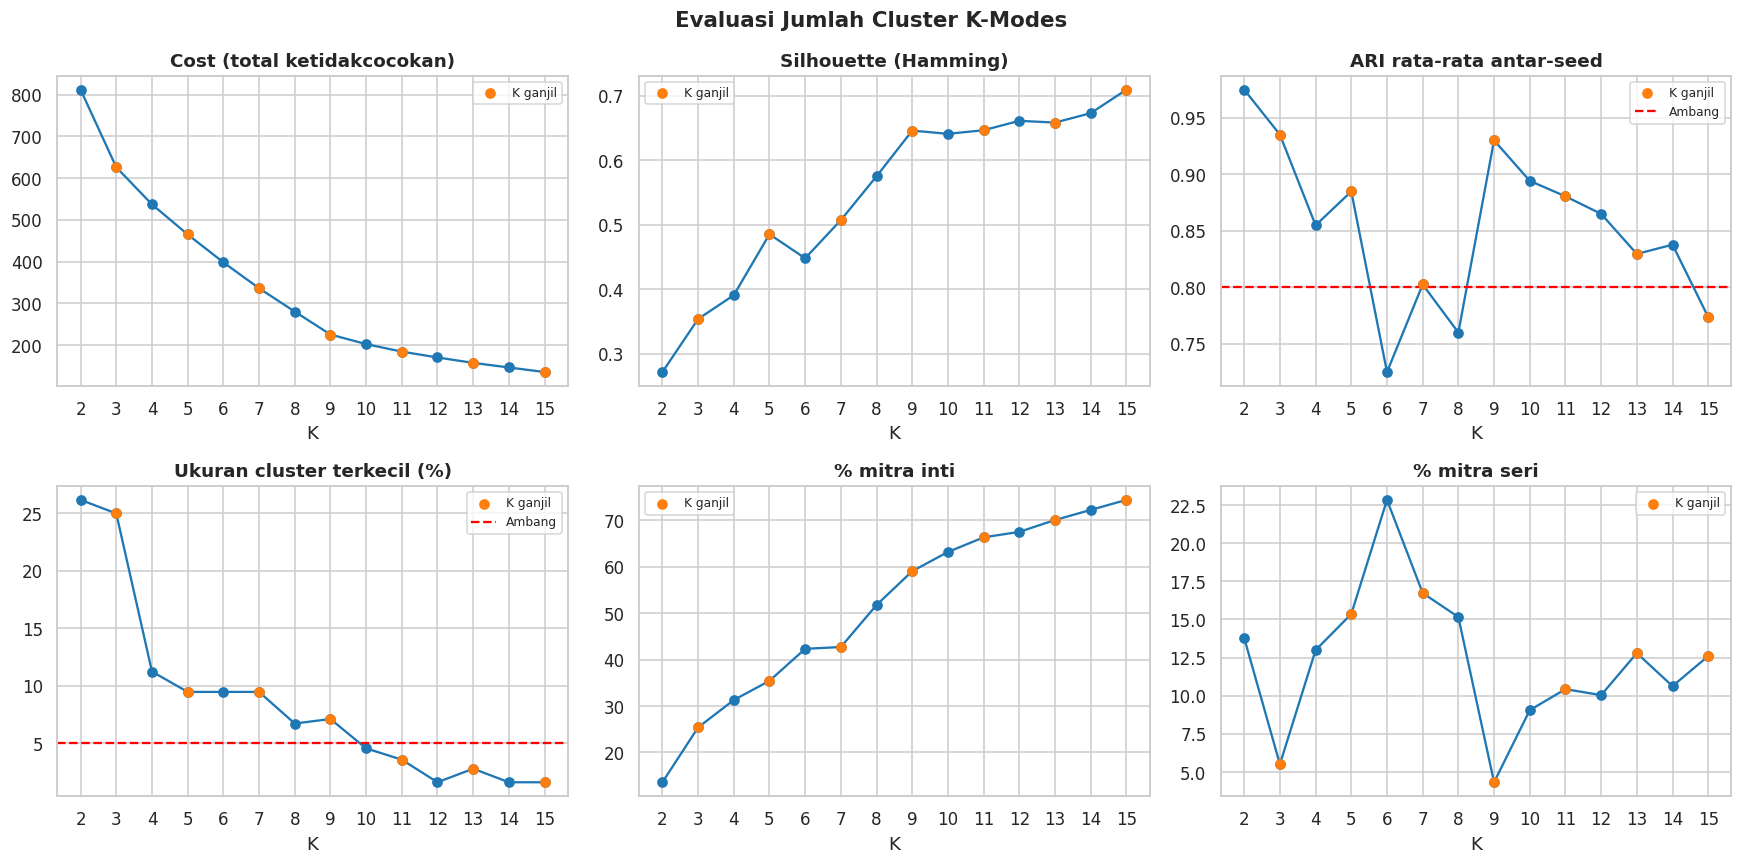

K dengan cost naik dibanding K sebelumnya (tanda optimum lokal): tidak ada


In [37]:
# ============================================================
# E6. TABEL DAN GRAFIK EVALUASI K
# ============================================================

# Menampilkan tabel evaluasi (dibulatkan agar mudah dibaca)
display(evaluasi_k.round(3))

# Konfigurasi enam panel: (kolom, judul, garis ambang)
panel = [
    ("COST", "Cost (total ketidakcocokan)", None),
    ("SILHOUETTE", "Silhouette (Hamming)", None),
    ("ARI_RATA2", "ARI rata-rata antar-seed", AMBANG_ARI),
    ("UKURAN_MIN (%)", "Ukuran cluster terkecil (%)", AMBANG_UKURAN_MIN * 100),
    ("% INTI", "% mitra inti", None),
    ("% SERI", "% mitra seri", None),
]

# Penanda K ganjil
k_ganjil = evaluasi_k.index[evaluasi_k.index % 2 == 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (kolom, judul, ambang) in zip(axes.flat, panel):
    # Garis untuk semua K
    ax.plot(evaluasi_k.index, evaluasi_k[kolom], marker="o", color="tab:blue")
    # Titik oranye untuk K ganjil
    ax.scatter(k_ganjil, evaluasi_k.loc[k_ganjil, kolom], color="tab:orange", zorder=3, label="K ganjil")
    # Garis ambang (jika ada)
    if ambang is not None:
        ax.axhline(ambang, color="red", linestyle="--", label="Ambang")
    ax.set_title(judul, fontweight="bold")
    ax.set_xlabel("K")
    ax.set_xticks(evaluasi_k.index)
    ax.legend(fontsize=8)
plt.suptitle("Evaluasi Jumlah Cluster K-Modes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Pemeriksaan cost monoton turun
cost_naik = evaluasi_k["COST"].diff() > 0
print("K dengan cost naik dibanding K sebelumnya (tanda optimum lokal):",
      evaluasi_k.index[cost_naik].tolist() or "tidak ada")

### E7. Penerapan aturan pemilihan K
**Aturan (ditetapkan di A2, sebelum melihat hasil):**
1. **Lolos ukuran:** cluster terkecil ≥ 5% data.
2. **Lolos stabilitas:** ARI rata-rata ≥ 0,80.
3. **K ganjil** (arahan pembimbing, jika `HANYA_K_GANJIL = True`).
4. Dari K yang lolos, dipilih **silhouette tertinggi**. Jika seri, K terkecil.

**Output yang diharapkan:** tabel status setiap K dan `K_TERPILIH`.

In [38]:
# ============================================================
# E7. PENERAPAN ATURAN PEMILIHAN K
# ============================================================

def pilih_k(evaluasi, ambang_ukuran, ambang_ari, hanya_ganjil):
    """Mengembalikan (K terpilih, tabel status) sesuai aturan pemilihan K."""
    # Salinan agar tabel asli tidak berubah
    status = evaluasi[["SILHOUETTE", "ARI_RATA2", "UKURAN_MIN"]].copy()
    # Syarat 1: ukuran cluster terkecil
    status["LOLOS_UKURAN"] = status["UKURAN_MIN"] >= ambang_ukuran * len(df_clean)
    # Syarat 2: stabilitas antar-seed
    status["LOLOS_STABILITAS"] = status["ARI_RATA2"] >= ambang_ari
    # Syarat 3: K ganjil (selalu True jika batasan tidak dipakai)
    status["LOLOS_GANJIL"] = (status.index % 2 == 1) | (not hanya_ganjil)
    # Kandidat = memenuhi semua syarat
    status["KANDIDAT"] = status["LOLOS_UKURAN"] & status["LOLOS_STABILITAS"] & status["LOLOS_GANJIL"]
    # Tidak ada kandidat → kembalikan None
    if not status["KANDIDAT"].any():
        return None, status
    # Silhouette tertinggi di antara kandidat; idxmax mengambil K terkecil jika seri
    k_pilih = int(status.loc[status["KANDIDAT"], "SILHOUETTE"].idxmax())
    return k_pilih, status

# Menerapkan aturan utama
K_TERPILIH, status_k = pilih_k(evaluasi_k, AMBANG_UKURAN_MIN, AMBANG_ARI, HANYA_K_GANJIL)

# Menampilkan status setiap K
display(status_k.round(3))

# Menghentikan eksekusi jika tidak ada K yang memenuhi aturan
assert K_TERPILIH is not None, "Tidak ada K yang memenuhi aturan: tinjau ulang ambang"

# Daftar kandidat untuk uji bootstrap (E9)
kandidat_k = status_k.index[status_k["KANDIDAT"]].tolist()
print("K kandidat (lolos semua syarat):", kandidat_k)
print(f"K TERPILIH: {K_TERPILIH} "
      f"(silhouette = {evaluasi_k.loc[K_TERPILIH, 'SILHOUETTE']:.3f}, "
      f"ARI rata-rata = {evaluasi_k.loc[K_TERPILIH, 'ARI_RATA2']:.3f})")

,SILHOUETTE,ARI_RATA2,UKURAN_MIN,LOLOS_UKURAN,LOLOS_STABILITAS,LOLOS_GANJIL,KANDIDAT
K,,,,,,,
2,0.271,0.975,133,True,True,False,False
3,0.354,0.935,127,True,True,True,True
4,0.391,0.855,57,True,True,False,False
5,0.485,0.885,48,True,True,True,True
6,0.448,0.725,48,True,False,False,False
7,0.507,0.803,48,True,True,True,True
8,0.575,0.760,34,True,False,False,False
9,0.646,0.930,36,True,True,True,True
10,0.641,0.894,23,False,True,False,False


K kandidat (lolos semua syarat): [3, 5, 7, 9]
K TERPILIH: 9 (silhouette = 0.646, ARI rata-rata = 0.930)


### E8. Uji sensitivitas aturan pemilihan K
**Tujuan:** memeriksa apakah K terpilih **bergantung pada ambang** yang dipilih. Jika K yang sama muncul di berbagai kombinasi ambang, keputusan lebih kuat.

**Variasi yang diuji:**
- ukuran minimum 3%, 5%, 10%;
- ARI minimum 0,75, 0,80, 0,85;
- dengan dan tanpa batasan K ganjil.

**Cara membaca:** setiap sel berisi K terpilih untuk kombinasi tersebut. Sel bertanda "–" berarti tidak ada K yang lolos.

In [39]:
# ============================================================
# E8. UJI SENSITIVITAS ATURAN PEMILIHAN K
# ============================================================

# Wadah hasil sensitivitas
hasil_sensitivitas = []

# Mencoba setiap kombinasi ambang
for hanya_ganjil in [True, False]:
    for ambang_ukuran in [0.03, 0.05, 0.10]:
        for ambang_ari in [0.75, 0.80, 0.85]:
            # Menerapkan aturan dengan ambang yang sedang diuji
            k_pilih, _ = pilih_k(evaluasi_k, ambang_ukuran, ambang_ari, hanya_ganjil)
            hasil_sensitivitas.append({
                "Batasan": "Hanya K ganjil" if hanya_ganjil else "Semua K",
                "Ukuran min": f"{ambang_ukuran:.0%}",
                "ARI min": ambang_ari,
                "K terpilih": str(k_pilih) if k_pilih is not None else "–",
            })

# Tabel pivot: baris = batasan & ukuran minimum, kolom = ARI minimum
tabel_sensitivitas = (
    pd.DataFrame(hasil_sensitivitas)
    .pivot_table(index=["Batasan", "Ukuran min"], columns="ARI min", values="K terpilih", aggfunc="first")
)
display(tabel_sensitivitas)

ARI min                   0.75 0.80 0.85
Batasan        Ukuran min               
Hanya K ganjil 10%           3    3    3
               3%           11   11   11
               5%            9    9    9
Semua K        10%           4    4    4
               3%           11   11   11
               5%            9    9    9

### E9. Uji stabilitas bootstrap (subsampel 80%)
**Tujuan:** menguji apakah cluster tetap muncul ketika **sebagian data diambil ulang**. Uji ini lebih kuat daripada uji antar-seed, karena data yang dipakai benar-benar berubah.

**Metode (mengikuti Hennig, 2007):**
1. Ambil 80% mitra secara acak, ulangi 100 kali.
2. Latih K-Modes pada subsampel, lalu tetapkan cluster untuk mitra.
3. Bandingkan dengan solusi data penuh, khusus pada mitra yang ada di subsampel:
   - **ARI**: kemiripan partisi secara keseluruhan;
   - **Jaccard per cluster**: seberapa utuh setiap cluster muncul kembali.

**Acuan Jaccard (Hennig, 2007):**

| Rata-rata Jaccard | Arti |
|---|---|
| ≥ 0,75 | Cluster stabil |
| 0,60–0,75 | Ada pola, tetapi kurang stabil |
| ≤ 0,50 | Cluster "larut" (tidak stabil) |

Uji dijalankan untuk semua K kandidat dari E7.

In [40]:
# ============================================================
# E9. UJI STABILITAS BOOTSTRAP
# ============================================================

def stabilitas_bootstrap(k, label_referensi):
    """ARI per pengulangan & Jaccard rata-rata per cluster terhadap solusi data penuh."""
    # Generator acak dengan seed tetap agar hasil dapat direproduksi
    rng = np.random.default_rng(SEED_BOOTSTRAP)
    # Jumlah mitra dalam setiap subsampel
    ukuran_sub = int(FRAKSI_SUBSAMPEL * len(df_clean))
    # Wadah hasil
    daftar_ari, daftar_jaccard = [], []

    for _ in range(N_BOOTSTRAP):
        # Memilih indeks mitra secara acak tanpa pengembalian
        idx = rng.choice(len(df_clean), size=ukuran_sub, replace=False)
        # Melatih model pada profil subsampel; seed diambil dari generator
        model_sub = latih_kmodes(buat_profil(df_clean.iloc[idx]), k,
                                 seed=int(rng.integers(1_000_000)), n_init=N_INIT_BOOTSTRAP)
        # Label subsampel dan label referensi, hanya untuk mitra terpilih
        label_sub = model_sub.predict(X_kmodes[idx]).astype(int)
        label_ref = label_referensi[idx]
        # ARI antara partisi subsampel dan referensi
        daftar_ari.append(adjusted_rand_score(label_ref, label_sub))

        # Jaccard: untuk setiap cluster referensi, cari cluster subsampel yang paling mirip
        jaccard_iterasi = []
        for c in range(k):
            anggota_ref = label_ref == c                     # Anggota cluster c di referensi
            if anggota_ref.sum() == 0:                       # Cluster tidak terwakili di subsampel
                jaccard_iterasi.append(np.nan)
                continue
            # Jaccard = irisan / gabungan, maksimum terhadap semua cluster subsampel
            jaccard_iterasi.append(max(
                (anggota_ref & (label_sub == c2)).sum() / (anggota_ref | (label_sub == c2)).sum()
                for c2 in np.unique(label_sub)
            ))
        daftar_jaccard.append(jaccard_iterasi)

    # Rata-rata Jaccard per cluster (abaikan NaN)
    return np.array(daftar_ari), np.nanmean(np.array(daftar_jaccard), axis=0)

# Menjalankan uji untuk setiap K kandidat
ringkasan_bootstrap = []
jaccard_per_k = {}
for k in kandidat_k:
    ari_boot, jaccard_boot = stabilitas_bootstrap(k, label_terbaik[k])
    jaccard_per_k[k] = jaccard_boot
    ringkasan_bootstrap.append({
        "K": k,
        "ARI bootstrap rata-rata": ari_boot.mean(),
        "ARI bootstrap persentil-5": np.percentile(ari_boot, 5),
        "Jaccard terendah antar-cluster": jaccard_boot.min(),
        "Cluster dengan Jaccard < 0,75": int((jaccard_boot < 0.75).sum()),
    })
    print(f"Bootstrap K={k} selesai")

# Tabel ringkasan bootstrap
ringkasan_bootstrap = pd.DataFrame(ringkasan_bootstrap).set_index("K")
display(ringkasan_bootstrap.round(3))

Bootstrap K=3 selesai
Bootstrap K=5 selesai
Bootstrap K=7 selesai
Bootstrap K=9 selesai


,ARI bootstrap rata-rata,ARI bootstrap persentil-5,Jaccard terendah antar-cluster,"Cluster dengan Jaccard < 0,75"
K,,,,
3,0.866,0.690,0.857,0
5,0.782,0.528,0.580,1
7,0.700,0.563,0.546,3
9,0.904,0.798,0.827,0


### E10. Model final
**Tujuan:** menetapkan model untuk `K_TERPILIH` dan menambahkan hasilnya ke data.

**Proses:**
1. Nomor cluster diurutkan ulang dari anggota **terbanyak** (Cluster 1) ke tersedikit, agar mudah dibaca. Keanggotaan tidak berubah, hanya nomornya.
2. Setiap mitra mendapat informasi:
   - `CLUSTER`: nomor cluster;
   - `JARAK_KE_MODUS`: jumlah fitur yang berbeda dari modus cluster (0–3);
   - `STATUS_KEANGGOTAAN`:
     - **Inti**: cocok persis dengan modus;
     - **Periferal**: berbeda di sebagian fitur, tetapi jelas paling dekat ke cluster ini;
     - **Periferal (seri)**: berjarak sama ke beberapa modus, sehingga cluster ditentukan nomor indeks.

**Validasi:** jumlah `JARAK_KE_MODUS` seluruh mitra harus sama dengan cost model.

In [41]:
# ============================================================
# E10. MODEL FINAL
# ============================================================

# Model dan label terbaik untuk K terpilih (dari E5)
model_final = model_terbaik[K_TERPILIH]
label_asli = label_terbaik[K_TERPILIH]

# Urutan cluster lama berdasarkan jumlah anggota (terbanyak → tersedikit)
urutan_cluster = pd.Series(label_asli).value_counts().index.tolist()
# Peta nomor lama → nomor baru (mulai dari 1)
peta_label = {lama: baru for baru, lama in enumerate(urutan_cluster, start=1)}

# Nomor cluster baru untuk setiap mitra
df_clean["CLUSTER"] = pd.Series(label_asli).map(peta_label).to_numpy()

# Modus (pusat) setiap cluster dengan nomor baru
modus_cluster = pd.DataFrame(model_final.cluster_centroids_, columns=FITUR_KMODES)
modus_cluster.index = [peta_label[i] for i in range(K_TERPILIH)]
modus_cluster = modus_cluster.sort_index().rename_axis("CLUSTER")

# Jarak setiap mitra ke setiap modus (urutan kolom mengikuti nomor lama)
jarak_final = jarak_ke_modus(model_final, X_kmodes)
# Jarak ke modus terdekat
df_clean["JARAK_KE_MODUS"] = jarak_final.min(axis=1)
# Seri: lebih dari satu modus berjarak minimum
seri_final = (jarak_final == jarak_final.min(axis=1)[:, None]).sum(axis=1) > 1

# Status keanggotaan berdasarkan jarak dan seri
df_clean["STATUS_KEANGGOTAAN"] = np.select(
    [df_clean["JARAK_KE_MODUS"] == 0, seri_final],          # Kondisi diperiksa berurutan
    ["Inti", "Periferal (seri)"],                            # Label untuk masing-masing kondisi
    default="Periferal",                                     # Selain itu
)

# --- Validasi ---
# Total jarak ke modus = cost model
assert np.isclose(df_clean["JARAK_KE_MODUS"].sum(), model_final.cost_), "Total jarak ≠ cost"
# Semua cluster memiliki anggota
assert df_clean["CLUSTER"].nunique() == K_TERPILIH, "Ada cluster tanpa anggota"

print(f"Model final: K = {K_TERPILIH}, cost = {model_final.cost_:.0f}")
print("\nModus setiap cluster:")
display(modus_cluster)
print("Status keanggotaan:")
display(df_clean["STATUS_KEANGGOTAAN"].value_counts().to_frame("JUMLAH MITRA"))

Model final: K = 9, cost = 225

Modus setiap cluster:


,SEKTOR_ANALISIS,LOKASI_ANALISIS,UNIT_ANALISIS
CLUSTER,,,
1,Sektor Perdagangan,KOTA BIMA,UP3 BIMA
2,Sektor Industri,KOTA BIMA,UP3 BIMA
3,Sektor Jasa,SUMBAWA,UP3 SUMBAWA
4,Sektor Pertanian,LOMBOK BARAT,UP3 MATARAM
5,Sektor Pertanian,LOMBOK TENGAH,UPT MATARAM
6,Sektor Jasa,KOTA BIMA,UP3 BIMA
7,Sektor Jasa,LOMBOK TIMUR,UP3 SELAPARANG
8,Sektor Jasa,KOTA MATARAM,UP2D NTB
9,Sektor Perdagangan,KOTA MATARAM,UP2B NTB


Status keanggotaan:


,JUMLAH MITRA
STATUS_KEANGGOTAAN,
Inti,300
Periferal,186
Periferal (seri),22


---
# BAGIAN F — PROFILING DAN PENAMAAN CLUSTER

**Prinsip:** K-Modes **membentuk** cluster; profiling **menjelaskan isinya**.
- Profil fitur (sektor, lokasi, unit) menunjukkan seberapa murni setiap cluster.
- Profil periode menjelaskan **kapan** anggota cluster disalurkan. Periode **bukan** penyebab terbentuknya cluster, karena tahun tidak dipakai sebagai fitur.

### F1. Profil ringkas setiap cluster
**Tujuan:** tabel utama profil cluster.

**Isi kolom:**
- jumlah dan persentase anggota;
- kategori dominan setiap fitur beserta persentasenya;
- % inti dan % seri.

**Cara membaca:** persentase dominan yang tinggi (misalnya ≥ 75%) berarti cluster tersebut "murni" untuk fitur itu. Persentase rendah berarti anggota cluster beragam pada fitur tersebut.

In [42]:
# ============================================================
# F1. PROFIL RINGKAS SETIAP CLUSTER
# ============================================================

def dominan(kolom):
    """Kategori paling sering dan persentasenya, per cluster."""
    # Proporsi setiap kategori di dalam setiap cluster (baris = cluster)
    proporsi = pd.crosstab(df_clean["CLUSTER"], df_clean[kolom].astype(str), normalize="index")
    # Kategori dengan proporsi terbesar dan nilai proporsinya (dalam %)
    return proporsi.idxmax(axis=1), (proporsi.max(axis=1) * 100).round(1)

# Kerangka tabel: jumlah anggota per cluster
profil_cluster = df_clean["CLUSTER"].value_counts().sort_index().to_frame("JUMLAH MITRA")
# Persentase anggota terhadap total mitra
profil_cluster["% MITRA"] = (profil_cluster["JUMLAH MITRA"] / len(df_clean) * 100).round(1)

# Kategori dominan dan persentasenya untuk setiap fitur
for kolom, nama in [("SEKTOR_ANALISIS", "SEKTOR"), ("LOKASI_ANALISIS", "LOKASI"), ("UNIT_ANALISIS", "UNIT")]:
    kategori, persen = dominan(kolom)
    profil_cluster[f"{nama} DOMINAN"] = kategori
    profil_cluster[f"% {nama}"] = persen

# Persentase anggota inti dan seri per cluster
profil_cluster["% INTI"] = (df_clean.groupby("CLUSTER")["STATUS_KEANGGOTAAN"]
                            .apply(lambda s: (s == "Inti").mean() * 100).round(1))
profil_cluster["% SERI"] = (df_clean.groupby("CLUSTER")["STATUS_KEANGGOTAAN"]
                            .apply(lambda s: (s == "Periferal (seri)").mean() * 100).round(1))

profil_cluster = profil_cluster.rename_axis("CLUSTER")
display(profil_cluster)

,JUMLAH MITRA,% MITRA,SEKTOR DOMINAN,% SEKTOR,LOKASI DOMINAN,% LOKASI,UNIT DOMINAN,% UNIT,% INTI,% SERI
CLUSTER,,,,,,,,,,
1,78,15.4,Sektor Perdagangan,96.2,KOTA BIMA,70.5,UP3 BIMA,100.0,69.2,3.8
2,64,12.6,Sektor Industri,100.0,KOTA BIMA,54.7,UP3 BIMA,100.0,54.7,0.0
3,62,12.2,Sektor Jasa,69.4,SUMBAWA,100.0,UP3 SUMBAWA,100.0,69.4,0.0
4,61,12.0,Sektor Pertanian,55.7,LOMBOK BARAT,100.0,UP3 MATARAM,91.8,52.5,8.2
5,59,11.6,Sektor Pertanian,57.6,LOMBOK TENGAH,93.2,UPT MATARAM,100.0,50.8,0.0
6,55,10.8,Sektor Jasa,100.0,KOTA BIMA,67.3,UP3 BIMA,100.0,67.3,0.0
7,48,9.4,Sektor Jasa,43.8,LOMBOK TIMUR,100.0,UP3 SELAPARANG,100.0,43.8,0.0
8,45,8.9,Sektor Jasa,66.7,KOTA MATARAM,77.8,UP2D NTB,86.7,53.3,26.7
9,36,7.1,Sektor Perdagangan,72.2,KOTA MATARAM,91.7,UP2B NTB,97.2,66.7,5.6


### F2. Komposisi fitur di setiap cluster (heatmap)
**Tujuan:** menampilkan **distribusi lengkap**, bukan hanya kategori dominan. Setiap baris adalah satu cluster dan berjumlah 100%.

**Pertanyaan yang dijawab:** fitur mana yang paling membedakan setiap cluster, dan seberapa beragam isi setiap cluster?

**Catatan:** karena LOKASI dan UNIT sangat terkait (D2), heatmap lokasi dan unit akan terlihat mirip. Hal ini wajar dan merupakan konsekuensi desain (D3), bukan temuan baru.

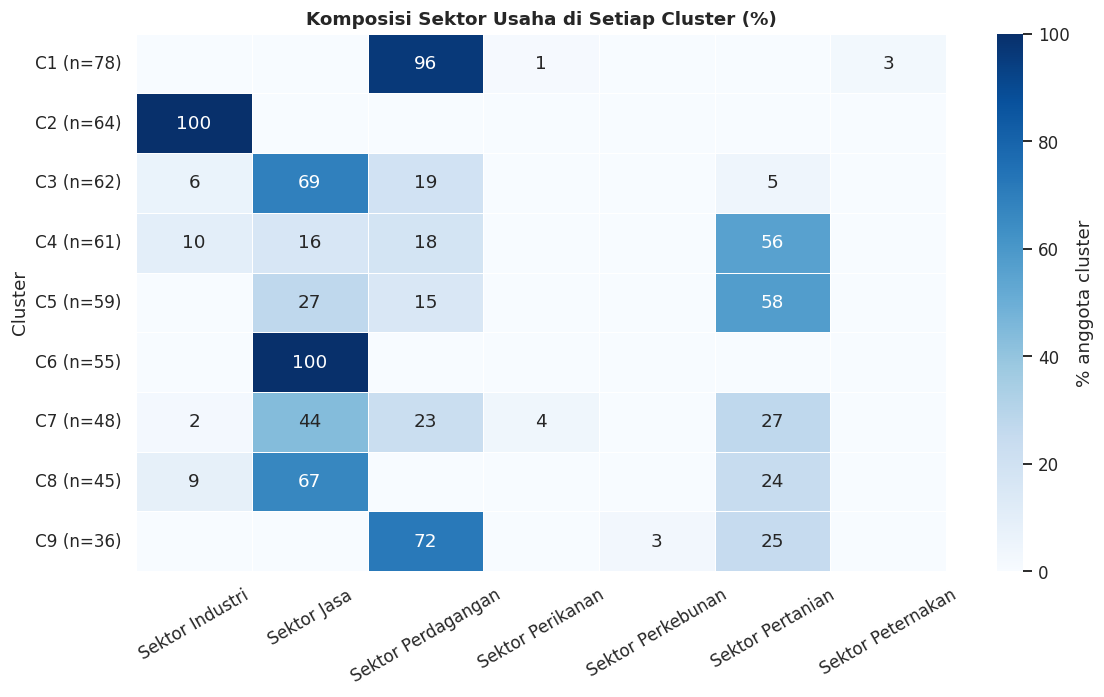

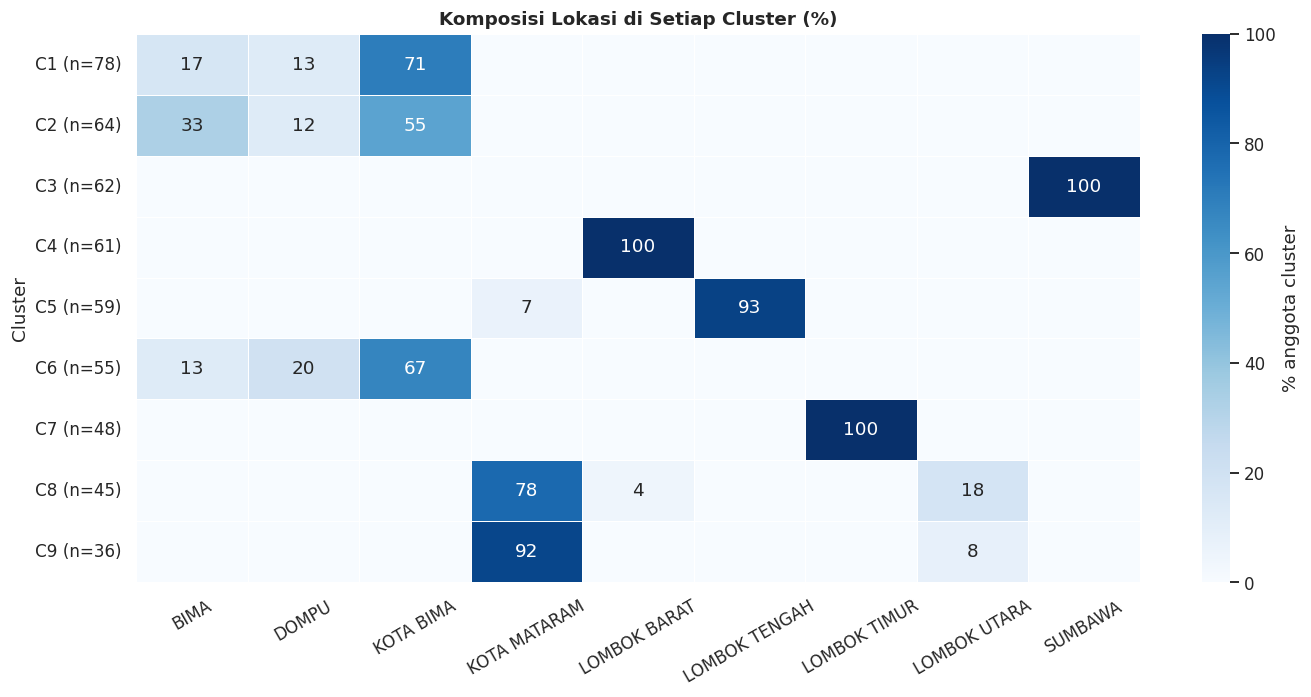

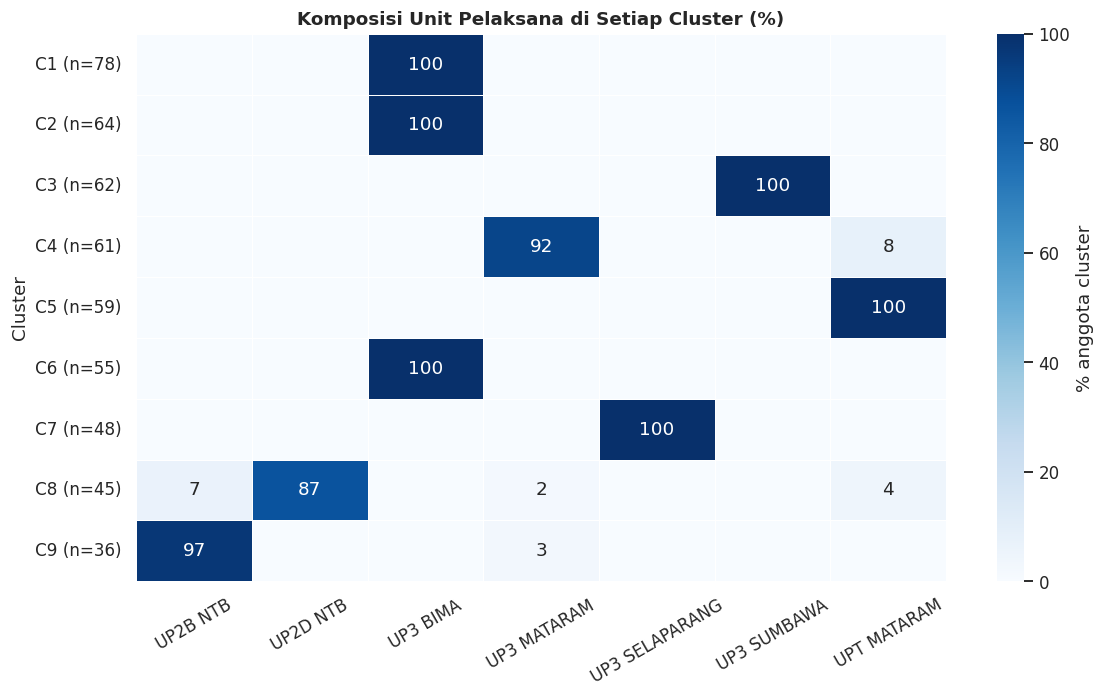

In [43]:
# ============================================================
# F2. KOMPOSISI FITUR DI SETIAP CLUSTER
# ============================================================

def heatmap_komposisi(kolom, judul):
    """Heatmap persentase kategori di dalam setiap cluster (baris = 100%)."""
    # Proporsi (%) setiap kategori per cluster
    tabel = pd.crosstab(df_clean["CLUSTER"], df_clean[kolom].astype(str), normalize="index") * 100
    # Label baris: nomor cluster dan jumlah anggota
    tabel.index = [f"C{c} (n={n})" for c, n in profil_cluster["JUMLAH MITRA"].items()]
    # Anotasi: angka bulat untuk sel > 0, kosong untuk sel 0
    anotasi = tabel.round(0).astype(int).astype(str).where(tabel > 0, "")
    fig, ax = plt.subplots(figsize=(max(8, 1.1 * tabel.shape[1] + 3), 0.5 * len(tabel) + 2))
    sns.heatmap(tabel, annot=anotasi, fmt="", cmap="Blues", vmin=0, vmax=100, linewidths=0.5,
                cbar_kws={"label": "% anggota cluster"}, ax=ax)
    ax.set_title(judul, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Cluster")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

# Satu heatmap untuk setiap fitur clustering
heatmap_komposisi("SEKTOR_ANALISIS", "Komposisi Sektor Usaha di Setiap Cluster (%)")
heatmap_komposisi("LOKASI_ANALISIS", "Komposisi Lokasi di Setiap Cluster (%)")
heatmap_komposisi("UNIT_ANALISIS", "Komposisi Unit Pelaksana di Setiap Cluster (%)")

### F3. Kekhasan sektor setiap cluster (lift)
**Tujuan:** menunjukkan sektor yang **khas** untuk sebuah cluster, bukan sekadar sektor yang paling banyak secara umum.

$$\text{Lift} = \frac{P(\text{sektor} \mid \text{cluster})}{P(\text{sektor keseluruhan})}$$

**Cara membaca:**
- Lift > 1: sektor itu **lebih sering** muncul di cluster ini dibanding rata-rata seluruh mitra (warna merah).
- Lift < 1: **lebih jarang** (warna biru).
- Contoh: lift 2,0 berarti porsi sektor tersebut di cluster ini dua kali lipat porsinya di seluruh data.

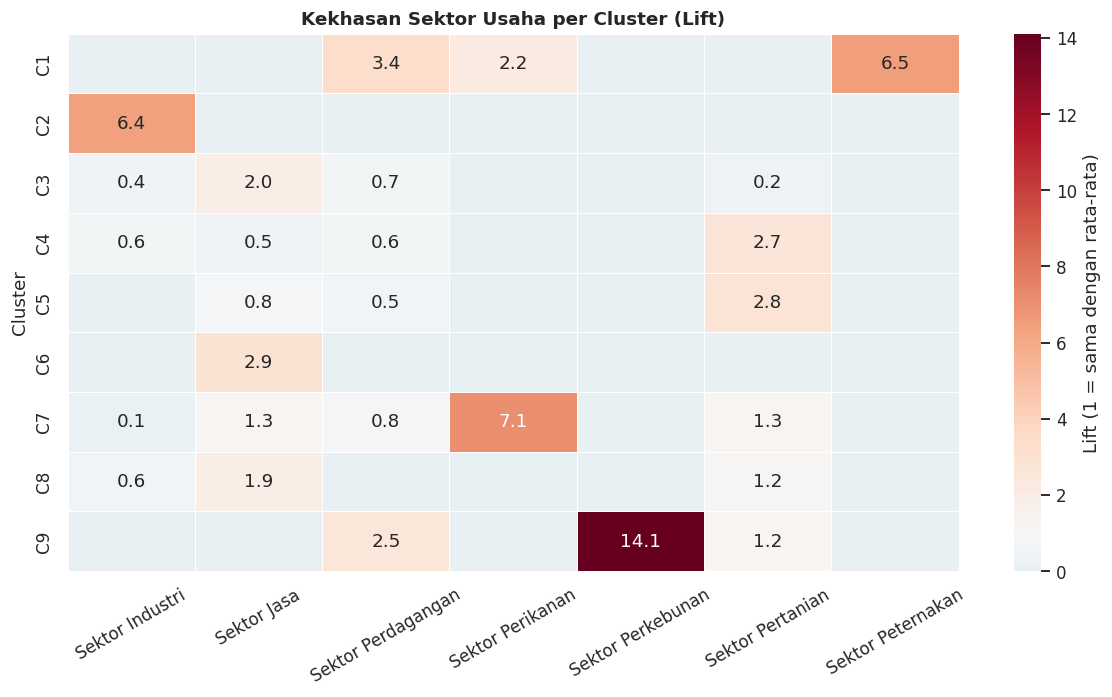

In [44]:
# ============================================================
# F3. KEKHASAN SEKTOR SETIAP CLUSTER (LIFT)
# ============================================================

# Proporsi sektor di dalam setiap cluster
proporsi_dalam_cluster = pd.crosstab(df_clean["CLUSTER"], df_clean["SEKTOR_ANALISIS"].astype(str), normalize="index")
# Proporsi sektor di seluruh data
proporsi_keseluruhan = df_clean["SEKTOR_ANALISIS"].astype(str).value_counts(normalize=True)
# Lift = proporsi di cluster ÷ proporsi keseluruhan (kolom disejajarkan otomatis)
lift_sektor = proporsi_dalam_cluster.div(proporsi_keseluruhan, axis=1)
# Label baris cluster
lift_sektor.index = [f"C{c}" for c in lift_sektor.index]

# Anotasi hanya untuk sel yang sektornya ada di cluster tersebut
anotasi = lift_sektor.round(1).astype(str).where(lift_sektor > 0, "")
fig, ax = plt.subplots(figsize=(11, 0.5 * len(lift_sektor) + 2))
sns.heatmap(lift_sektor, annot=anotasi, fmt="", cmap="RdBu_r", center=1, linewidths=0.5,
            cbar_kws={"label": "Lift (1 = sama dengan rata-rata)"}, ax=ax)
ax.set_title("Kekhasan Sektor Usaha per Cluster (Lift)", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Cluster")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### F4. Profil periode salur setiap cluster
**Tujuan:** menjelaskan **kapan** anggota setiap cluster disalurkan.

**Mengapa median dan IQR, bukan min/maks?** Min dan maks sangat dipengaruhi satu mitra saja. Median dan rentang kuartil (Q1–Q3) menggambarkan "tahun khas" anggota cluster.

**Batasan interpretasi:** tahun **tidak** dipakai untuk membentuk cluster. Pola waktu yang terlihat di sini adalah ciri yang **menyertai** kombinasi sektor-wilayah, bukan penyebab terbentuknya cluster.

In [45]:
# ============================================================
# F4. PROFIL PERIODE SALUR SETIAP CLUSTER
# ============================================================

# Jumlah mitra per cluster × periode; kolom diurutkan sesuai periode
periode_cluster = (
    pd.crosstab(df_clean["CLUSTER"], df_clean["PERIODE SALUR"].astype(str))
    .reindex(columns=LABEL_PERIODE, fill_value=0)
)
# Persentase per baris (setiap cluster = 100%)
periode_cluster_persen = (periode_cluster.div(periode_cluster.sum(axis=1), axis=0) * 100).round(1)

# Tahun salur sebagai bilangan bulat biasa untuk statistik
tahun_int = df_clean["TAHUN SALUR"].astype(int)
# Statistik tahun salur per cluster: median, Q1, Q3
statistik_tahun = tahun_int.groupby(df_clean["CLUSTER"]).agg(
    MEDIAN=lambda s: int(s.median()),            # Tahun tengah
    Q1=lambda s: int(s.quantile(0.25)),          # Kuartil bawah
    Q3=lambda s: int(s.quantile(0.75)),          # Kuartil atas
)
# Periode dengan anggota terbanyak per cluster
statistik_tahun["PERIODE DOMINAN"] = periode_cluster.idxmax(axis=1)

print("Jumlah mitra per cluster dan periode:")
display(periode_cluster)
print("Persentase per cluster (baris = 100%):")
display(periode_cluster_persen)
print("Statistik tahun salur per cluster:")
display(statistik_tahun)

Jumlah mitra per cluster dan periode:


PERIODE SALUR,1993–1997,1998–2002,2003–2007,2008–2012,2013–2017,2018–2020
CLUSTER,,,,,,
1,46,10,12,10,0,0
2,53,2,5,4,0,0
3,42,7,2,11,0,0
4,23,23,10,4,0,1
5,33,20,1,4,0,1
6,46,2,5,2,0,0
7,25,7,8,8,0,0
8,9,19,10,6,0,1
9,8,13,6,8,0,1


Persentase per cluster (baris = 100%):


PERIODE SALUR,1993–1997,1998–2002,2003–2007,2008–2012,2013–2017,2018–2020
CLUSTER,,,,,,
1,59.0,12.8,15.4,12.8,0.0,0.0
2,82.8,3.1,7.8,6.2,0.0,0.0
3,67.7,11.3,3.2,17.7,0.0,0.0
4,37.7,37.7,16.4,6.6,0.0,1.6
5,55.9,33.9,1.7,6.8,0.0,1.7
6,83.6,3.6,9.1,3.6,0.0,0.0
7,52.1,14.6,16.7,16.7,0.0,0.0
8,20.0,42.2,22.2,13.3,0.0,2.2
9,22.2,36.1,16.7,22.2,0.0,2.8


Statistik tahun salur per cluster:


,MEDIAN,Q1,Q3,PERIODE DOMINAN
CLUSTER,,,,
1,1997,1996,2003,1993–1997
2,1996,1995,1996,1993–1997
3,1997,1996,1998,1993–1997
4,1998,1996,2002,1993–1997
5,1996,1996,1998,1993–1997
6,1996,1994,1997,1993–1997
7,1996,1996,2004,1993–1997
8,1999,1998,2006,1998–2002
9,2000,1998,2006,1998–2002


### F5. Status keanggotaan per cluster
**Tujuan:** menunjukkan **kejelasan** setiap cluster.

**Cara membaca:**
- Cluster dengan porsi **inti** besar memiliki identitas yang jelas.
- Cluster dengan porsi **periferal (seri)** besar sebagian keanggotaannya ditentukan aturan teknis. Nama cluster seperti ini harus dibaca lebih hati-hati.

STATUS_KEANGGOTAAN,Inti,Periferal,Periferal (seri)
C1,54,21,3
C2,35,29,0
C3,43,19,0
C4,32,24,5
C5,30,29,0
C6,37,18,0
C7,21,27,0
C8,24,9,12
C9,24,10,2


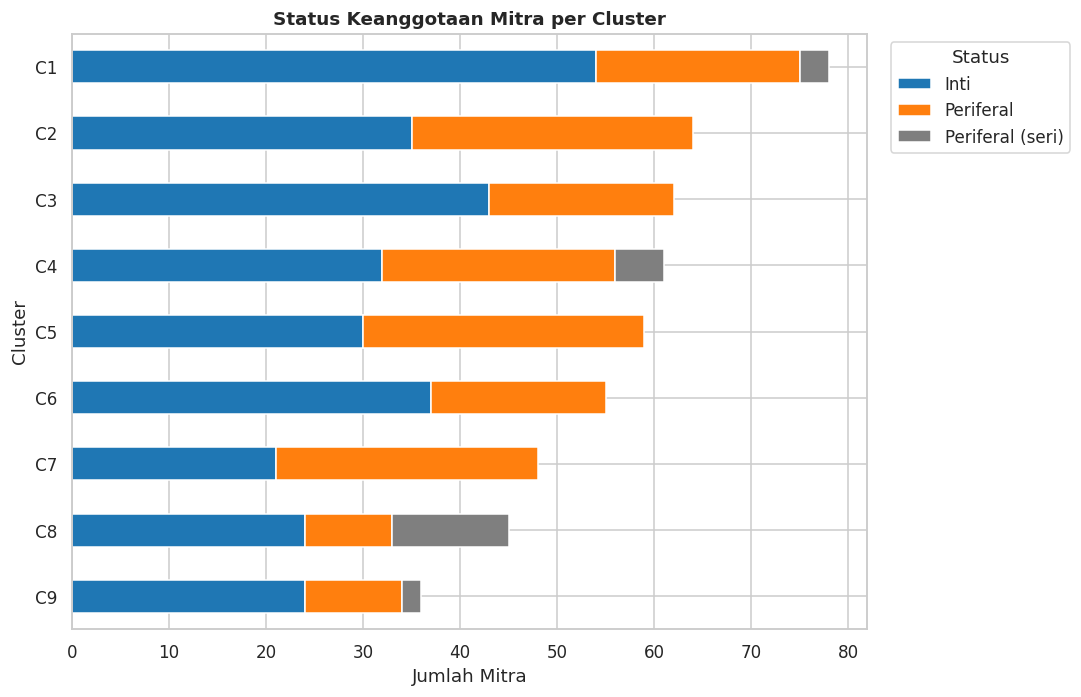

In [46]:
# ============================================================
# F5. STATUS KEANGGOTAAN PER CLUSTER
# ============================================================

# Urutan status agar warna konsisten
urutan_status = ["Inti", "Periferal", "Periferal (seri)"]
# Jumlah mitra per cluster × status
status_cluster = (
    pd.crosstab(df_clean["CLUSTER"], df_clean["STATUS_KEANGGOTAAN"])
    .reindex(columns=urutan_status, fill_value=0)
)
# Label baris cluster
status_cluster.index = [f"C{c}" for c in status_cluster.index]
display(status_cluster)

# Grafik batang horizontal bertumpuk
ax = status_cluster.plot(kind="barh", stacked=True, figsize=(10, 0.5 * len(status_cluster) + 2),
                         color=["tab:blue", "tab:orange", "tab:grey"])
ax.invert_yaxis()                                     # C1 di paling atas
ax.set_title("Status Keanggotaan Mitra per Cluster", fontweight="bold")
ax.set_xlabel("Jumlah Mitra")
ax.set_ylabel("Cluster")
ax.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### F6. Penamaan cluster otomatis
**Tujuan:** memberi nama yang **sesuai dengan isi cluster**, menggunakan aturan tertulis yang dapat diperiksa ulang.

**Format nama:** `[Sektor] – [Lokasi] ([Unit])`

**Aturan untuk setiap komponen (berdasarkan persentase kategori dominan):**

| Persentase dominan | Sektor | Lokasi | Unit |
|---|---|---|---|
| ≥ 75% | nama sektor (contoh: "Jasa") | nama lokasi | nama unit |
| 50–75% | "Jasa (dominan)" | "Kota Bima dsk." | "mayoritas UP3 BIMA" |
| < 50% | "Multisektor" | "Lintas lokasi" | "lintas unit" |

"dsk." berarti *dan sekitarnya*: lokasi tersebut terbanyak, tetapi anggota cluster juga tersebar di lokasi lain.

**Mengapa nama tidak diketik manual?** Nama yang diketik manual berisiko tidak sesuai dengan isi cluster, terutama jika nomor cluster berubah saat notebook dijalankan ulang.

In [47]:
# ============================================================
# F6. PENAMAAN CLUSTER OTOMATIS
# ============================================================

def komponen_nama(proporsi, jenis):
    """Menyusun satu komponen nama berdasarkan kategori dominan dan persentasenya."""
    # Kategori dengan proporsi terbesar
    kategori = proporsi.idxmax()
    # Proporsi kategori tersebut (0–1)
    nilai = proporsi.max()
    if jenis == "sektor":
        nama = kategori.replace("Sektor ", "")              # "Sektor Jasa" → "Jasa"
        if nilai >= AMBANG_MURNI:
            return nama
        return f"{nama} (dominan)" if nilai >= AMBANG_DOMINAN else "Multisektor"
    if jenis == "lokasi":
        nama = kategori.title()                             # "KOTA BIMA" → "Kota Bima"
        if nilai >= AMBANG_MURNI:
            return nama
        return f"{nama} dsk." if nilai >= AMBANG_DOMINAN else "Lintas lokasi"
    # jenis == "unit"
    if nilai >= AMBANG_MURNI:
        return kategori
    return f"mayoritas {kategori}" if nilai >= AMBANG_DOMINAN else "lintas unit"

# Proporsi kategori per cluster untuk setiap fitur
proporsi_sektor = pd.crosstab(df_clean["CLUSTER"], df_clean["SEKTOR_ANALISIS"].astype(str), normalize="index")
proporsi_lokasi = pd.crosstab(df_clean["CLUSTER"], df_clean["LOKASI_ANALISIS"].astype(str), normalize="index")
proporsi_unit = pd.crosstab(df_clean["CLUSTER"], df_clean["UNIT_ANALISIS"].astype(str), normalize="index")

# Menyusun nama untuk setiap cluster
nama_cluster = {}
for c in profil_cluster.index:
    sektor = komponen_nama(proporsi_sektor.loc[c], "sektor")
    lokasi = komponen_nama(proporsi_lokasi.loc[c], "lokasi")
    unit = komponen_nama(proporsi_unit.loc[c], "unit")
    nama_cluster[c] = f"{sektor} – {lokasi} ({unit})"

# Peringatan jika ada nama ganda (dua cluster dengan komposisi dominan sama)
nama_ganda = pd.Series(nama_cluster).duplicated(keep=False)
if nama_ganda.any():
    print("PERHATIAN: ada nama cluster yang sama; bedakan dengan melihat profil F1–F4.")

# Menambahkan nama ke data mitra dan tabel profil
df_clean["NAMA_CLUSTER"] = df_clean["CLUSTER"].map(nama_cluster)
profil_cluster["NAMA_CLUSTER"] = profil_cluster.index.map(nama_cluster)

# Tabel nama beserta dasar penamaannya
display(profil_cluster[["NAMA_CLUSTER", "JUMLAH MITRA", "% MITRA",
                        "SEKTOR DOMINAN", "% SEKTOR", "LOKASI DOMINAN", "% LOKASI",
                        "UNIT DOMINAN", "% UNIT"]])

,NAMA_CLUSTER,JUMLAH MITRA,% MITRA,SEKTOR DOMINAN,% SEKTOR,LOKASI DOMINAN,% LOKASI,UNIT DOMINAN,% UNIT
CLUSTER,,,,,,,,,
1,Perdagangan – Kota Bima dsk. (UP3 BIMA),78,15.4,Sektor Perdagangan,96.2,KOTA BIMA,70.5,UP3 BIMA,100.0
2,Industri – Kota Bima dsk. (UP3 BIMA),64,12.6,Sektor Industri,100.0,KOTA BIMA,54.7,UP3 BIMA,100.0
3,Jasa (dominan) – Sumbawa (UP3 SUMBAWA),62,12.2,Sektor Jasa,69.4,SUMBAWA,100.0,UP3 SUMBAWA,100.0
4,Pertanian (dominan) – Lombok Barat (UP3 MATARAM),61,12.0,Sektor Pertanian,55.7,LOMBOK BARAT,100.0,UP3 MATARAM,91.8
5,Pertanian (dominan) – Lombok Tengah (UPT MATARAM),59,11.6,Sektor Pertanian,57.6,LOMBOK TENGAH,93.2,UPT MATARAM,100.0
6,Jasa – Kota Bima dsk. (UP3 BIMA),55,10.8,Sektor Jasa,100.0,KOTA BIMA,67.3,UP3 BIMA,100.0
7,Multisektor – Lombok Timur (UP3 SELAPARANG),48,9.4,Sektor Jasa,43.8,LOMBOK TIMUR,100.0,UP3 SELAPARANG,100.0
8,Jasa (dominan) – Kota Mataram (UP2D NTB),45,8.9,Sektor Jasa,66.7,KOTA MATARAM,77.8,UP2D NTB,86.7
9,Perdagangan (dominan) – Kota Mataram (UP2B NTB),36,7.1,Sektor Perdagangan,72.2,KOTA MATARAM,91.7,UP2B NTB,97.2


### F7. Profil final cluster
**Tujuan:** satu tabel ringkas untuk laporan. Tabel ini menggabungkan nama, ukuran, komposisi sektor (dua teratas), sebaran lokasi (dua teratas), unit, dan periode dominan.

**Mengapa dua kategori teratas?** Satu kategori dominan saja dapat menyembunyikan keragaman, misalnya cluster "Pertanian (dominan)" yang 40% anggotanya dari sektor lain.

In [48]:
# ============================================================
# F7. PROFIL FINAL CLUSTER
# ============================================================

def dua_teratas(c, kolom, ubah_nama=None):
    """Teks dua kategori terbanyak beserta persentasenya untuk cluster c."""
    # Proporsi kategori di cluster c, diurutkan menurun
    proporsi = df_clean.loc[df_clean["CLUSTER"] == c, kolom].astype(str).value_counts(normalize=True).head(2)
    # Fungsi pengubah nama (opsional), misalnya menghapus kata "Sektor "
    ubah_nama = ubah_nama or (lambda x: x)
    # Gabungkan menjadi teks, contoh: "Jasa 71%, Perdagangan 18%"
    return ", ".join(f"{ubah_nama(k)} {v:.0%}" for k, v in proporsi.items())

# Menyusun profil final
profil_final = pd.DataFrame({
    "NAMA CLUSTER": profil_cluster["NAMA_CLUSTER"],
    "JUMLAH MITRA": profil_cluster["JUMLAH MITRA"],
    "% MITRA": profil_cluster["% MITRA"],
    "SEKTOR (2 teratas)": [dua_teratas(c, "SEKTOR_ANALISIS", lambda x: x.replace("Sektor ", "")) for c in profil_cluster.index],
    "LOKASI (2 teratas)": [dua_teratas(c, "LOKASI_ANALISIS", str.title) for c in profil_cluster.index],
    "UNIT (2 teratas)": [dua_teratas(c, "UNIT_ANALISIS") for c in profil_cluster.index],
    "PERIODE DOMINAN": statistik_tahun["PERIODE DOMINAN"],
    "MEDIAN TAHUN": statistik_tahun["MEDIAN"],
    "% INTI": profil_cluster["% INTI"],
}, index=profil_cluster.index)
display(profil_final)

,NAMA CLUSTER,JUMLAH MITRA,% MITRA,SEKTOR (2 teratas),LOKASI (2 teratas),UNIT (2 teratas),PERIODE DOMINAN,MEDIAN TAHUN,% INTI
CLUSTER,,,,,,,,,
1,Perdagangan – Kota Bima dsk. (UP3 BIMA),78,15.4,"Perdagangan 96%, Peternakan 3%","Kota Bima 71%, Bima 17%",UP3 BIMA 100%,1993–1997,1997,69.2
2,Industri – Kota Bima dsk. (UP3 BIMA),64,12.6,Industri 100%,"Kota Bima 55%, Bima 33%",UP3 BIMA 100%,1993–1997,1996,54.7
3,Jasa (dominan) – Sumbawa (UP3 SUMBAWA),62,12.2,"Jasa 69%, Perdagangan 19%",Sumbawa 100%,UP3 SUMBAWA 100%,1993–1997,1997,69.4
4,Pertanian (dominan) – Lombok Barat (UP3 MATARAM),61,12.0,"Pertanian 56%, Perdagangan 18%",Lombok Barat 100%,"UP3 MATARAM 92%, UPT MATARAM 8%",1993–1997,1998,52.5
5,Pertanian (dominan) – Lombok Tengah (UPT MATARAM),59,11.6,"Pertanian 58%, Jasa 27%","Lombok Tengah 93%, Kota Mataram 7%",UPT MATARAM 100%,1993–1997,1996,50.8
6,Jasa – Kota Bima dsk. (UP3 BIMA),55,10.8,Jasa 100%,"Kota Bima 67%, Dompu 20%",UP3 BIMA 100%,1993–1997,1996,67.3
7,Multisektor – Lombok Timur (UP3 SELAPARANG),48,9.4,"Jasa 44%, Pertanian 27%",Lombok Timur 100%,UP3 SELAPARANG 100%,1993–1997,1996,43.8
8,Jasa (dominan) – Kota Mataram (UP2D NTB),45,8.9,"Jasa 67%, Pertanian 24%","Kota Mataram 78%, Lombok Utara 18%","UP2D NTB 87%, UP2B NTB 7%",1998–2002,1999,53.3
9,Perdagangan (dominan) – Kota Mataram (UP2B NTB),36,7.1,"Perdagangan 72%, Pertanian 25%","Kota Mataram 92%, Lombok Utara 8%","UP2B NTB 97%, UP3 MATARAM 3%",1998–2002,2000,66.7


### F8. Ukuran setiap cluster beserta namanya
**Tujuan:** visual ringkas untuk presentasi. Setiap batang menunjukkan jumlah mitra per cluster beserta namanya.

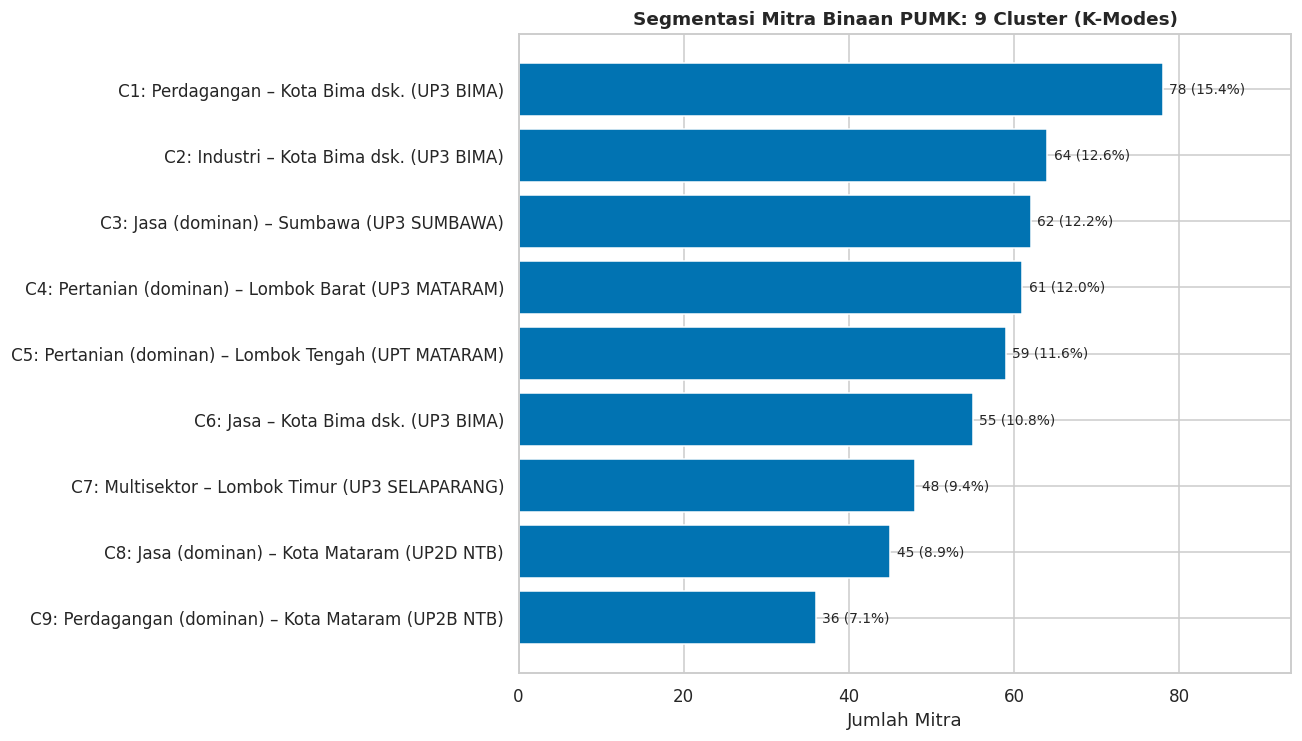

In [49]:
# ============================================================
# F8. UKURAN SETIAP CLUSTER BESERTA NAMANYA
# ============================================================

# Label sumbu Y: nomor dan nama cluster
label_y = [f"C{c}: {nama}" for c, nama in profil_cluster["NAMA_CLUSTER"].items()]

fig, ax = plt.subplots(figsize=(12, 0.6 * len(label_y) + 1.5))
# Batang horizontal jumlah mitra
batang = ax.barh(label_y, profil_cluster["JUMLAH MITRA"])
ax.invert_yaxis()                                     # C1 (terbesar) di paling atas
# Label jumlah dan persentase di ujung batang
for kotak, (n, persen) in zip(batang, profil_cluster[["JUMLAH MITRA", "% MITRA"]].values):
    ax.text(kotak.get_width() + 0.8, kotak.get_y() + kotak.get_height() / 2,
            f"{int(n)} ({persen:.1f}%)", va="center", fontsize=9)
ax.set_title(f"Segmentasi Mitra Binaan PUMK: {K_TERPILIH} Cluster (K-Modes)", fontweight="bold")
ax.set_xlabel("Jumlah Mitra")
ax.set_xlim(0, profil_cluster["JUMLAH MITRA"].max() * 1.2)
plt.tight_layout()
plt.show()

---
# BAGIAN G — SINTESIS & EKSPOR HASIL

### G1. Ringkasan hasil segmentasi
**Tujuan:** merangkum semua angka kunci segmentasi **langsung dari variabel hasil perhitungan**. Angka ini aman dikutip ke laporan, karena tidak ada yang diketik manual.

In [50]:
# ============================================================
# G1. RINGKASAN HASIL SEGMENTASI
# ============================================================

# Baris hasil evaluasi untuk K terpilih
baris_k = evaluasi_k.loc[K_TERPILIH]

print("RINGKASAN SEGMENTASI K-MODES")
print("=" * 70)
print(f"Jumlah mitra                    : {len(df_clean)}")
print(f"Fitur clustering                : {', '.join(FITUR_KMODES)}")
print(f"Jumlah profil unik              : {n_profil_unik}")
print(f"Batasan K ganjil                : {'Ya' if HANYA_K_GANJIL else 'Tidak'}")
print(f"K kandidat (lolos aturan)       : {kandidat_k}")
print(f"K terpilih                      : {K_TERPILIH}")
print(f"Silhouette (Hamming)            : {baris_k['SILHOUETTE']:.3f}")
print(f"Cost                            : {baris_k['COST']:.0f} "
      f"(rata-rata {baris_k['COST'] / len(df_clean):.2f} fitur berbeda per mitra dari 3 fitur)")
print(f"ARI antar-seed (rata-rata / min): {baris_k['ARI_RATA2']:.3f} / {baris_k['ARI_MIN']:.3f}")
print(f"ARI bootstrap rata-rata         : {ringkasan_bootstrap.loc[K_TERPILIH, 'ARI bootstrap rata-rata']:.3f}")
print(f"Jaccard bootstrap terendah      : {ringkasan_bootstrap.loc[K_TERPILIH, 'Jaccard terendah antar-cluster']:.3f}")
print(f"Ukuran cluster terkecil         : {int(baris_k['UKURAN_MIN'])} mitra ({baris_k['UKURAN_MIN (%)']:.1f}%)")
print(f"% mitra inti / seri             : {baris_k['% INTI']:.1f}% / {baris_k['% SERI']:.1f}%")
print("\nDaftar cluster:")
for c, baris in profil_final.iterrows():
    print(f"  C{c}: {baris['NAMA CLUSTER']}  —  {baris['JUMLAH MITRA']} mitra ({baris['% MITRA']}%)")

RINGKASAN SEGMENTASI K-MODES
Jumlah mitra                    : 508
Fitur clustering                : SEKTOR_ANALISIS, LOKASI_ANALISIS, UNIT_ANALISIS
Jumlah profil unik              : 45
Batasan K ganjil                : Ya
K kandidat (lolos aturan)       : [3, 5, 7, 9]
K terpilih                      : 9
Silhouette (Hamming)            : 0.646
Cost                            : 225 (rata-rata 0.44 fitur berbeda per mitra dari 3 fitur)
ARI antar-seed (rata-rata / min): 0.930 / 0.805
ARI bootstrap rata-rata         : 0.904
Jaccard bootstrap terendah      : 0.827
Ukuran cluster terkecil         : 36 mitra (7.1%)
% mitra inti / seri             : 59.1% / 4.3%

Daftar cluster:
  C1: Perdagangan – Kota Bima dsk. (UP3 BIMA)  —  78 mitra (15.4%)
  C2: Industri – Kota Bima dsk. (UP3 BIMA)  —  64 mitra (12.6%)
  C3: Jasa (dominan) – Sumbawa (UP3 SUMBAWA)  —  62 mitra (12.2%)
  C4: Pertanian (dominan) – Lombok Barat (UP3 MATARAM)  —  61 mitra (12.0%)
  C5: Pertanian (dominan) – Lombok Tengah (UPT 

### G2. Ekspor hasil ke Excel
**Tujuan:** menyimpan hasil dalam satu file Excel dengan beberapa sheet.

| Sheet | Isi |
|---|---|
| `Hasil_Segmentasi` | Setiap mitra dengan cluster, nama cluster, dan status keanggotaan |
| `Profil_Cluster` | Profil final per cluster (F7) |
| `Evaluasi_K` | Semua kriteria untuk setiap K (E5–E7) |
| `Bootstrap` | Hasil uji stabilitas bootstrap (E9) |
| `Cramers_V` | Asosiasi antarvariabel (D2) |
| `Tren_Tahunan`, `Tren_Periode` | Hasil analisis tren (C1, C3) |

**Privasi:** file hasil memuat nama mitra. Gunakan hanya untuk keperluan internal; **jangan** cantumkan daftar nama mitra di laporan publik.

In [51]:
# ============================================================
# G2. EKSPOR HASIL KE EXCEL
# ============================================================

# Lokasi file hasil
path_output = os.path.join(OUTPUT_DIR, "Hasil_Tren_Segmentasi_Mitra_PUMK.xlsx")

# Kolom yang diekspor untuk setiap mitra (tanpa variabel keuangan/sensitif)
kolom_ekspor = ["NO ID", "NAMA MITRA BINAAN", "NAMA USAHA", "SEKTOR_ANALISIS", "LOKASI_ANALISIS",
                "UNIT_ANALISIS", "TAHUN SALUR", "PERIODE SALUR", "CLUSTER", "NAMA_CLUSTER",
                "JARAK_KE_MODUS", "STATUS_KEANGGOTAAN"]

# Salinan data ekspor; PERIODE SALUR diubah ke teks agar tersimpan rapi di Excel
hasil_segmentasi = df_clean[kolom_ekspor].copy()
hasil_segmentasi["PERIODE SALUR"] = hasil_segmentasi["PERIODE SALUR"].astype(str)
hasil_segmentasi = hasil_segmentasi.sort_values(["CLUSTER", "TAHUN SALUR"])

# Tabel evaluasi lengkap: kriteria (E5) + status kelolosan (E7)
evaluasi_lengkap = evaluasi_k.join(status_k[["LOLOS_UKURAN", "LOLOS_STABILITAS", "LOLOS_GANJIL", "KANDIDAT"]])

# Menulis beberapa sheet ke satu file Excel
with pd.ExcelWriter(path_output, engine="openpyxl") as writer:
    hasil_segmentasi.to_excel(writer, sheet_name="Hasil_Segmentasi", index=False)   # Data per mitra
    profil_final.to_excel(writer, sheet_name="Profil_Cluster")                     # Profil per cluster
    evaluasi_lengkap.to_excel(writer, sheet_name="Evaluasi_K")                     # Evaluasi setiap K
    ringkasan_bootstrap.to_excel(writer, sheet_name="Bootstrap")                   # Uji bootstrap
    hasil_v_df.to_excel(writer, sheet_name="Cramers_V", index=False)               # Asosiasi antarvariabel
    trend_tahunan.to_excel(writer, sheet_name="Tren_Tahunan", index=False)         # Tren per tahun
    ringkasan_periode.to_excel(writer, sheet_name="Tren_Periode")                  # Tren per periode

print("File hasil tersimpan di:", path_output)

File hasil tersimpan di: /content/drive/MyDrive/DATA PKL/Hasil_Tren_Segmentasi_Mitra_PUMK.xlsx


### G3. Panduan interpretasi dan keterbatasan

**Yang BOLEH dinyatakan:**
- "Cluster C*n* didominasi mitra sektor X di wilayah Y yang dibina unit Z (persentase dari tabel F1/F7)."
- "Sebagian besar anggota cluster C*n* disalurkan pada periode P" (deskriptif, dari F4).
- "Segmentasi ini stabil" **hanya jika** ARI antar-seed ≥ 0,80 dan Jaccard bootstrap ≥ 0,75 (E5, E9).

**Yang TIDAK BOLEH dinyatakan:**
- Cluster tertentu "lebih baik", "lebih berhasil", atau "lebih berisiko". Tidak ada variabel kinerja atau pembayaran di dalam model.
- Tahun atau periode "menyebabkan" terbentuknya cluster. Tahun tidak dipakai sebagai fitur.
- Cluster adalah "tipe usaha". Cluster adalah **kombinasi** sektor, lokasi, dan unit.
- Penyebab naik-turunnya penyaluran, kecuali didukung dokumen PLN.

**Keterbatasan yang wajib ditulis di laporan:**
1. **Pembobotan wilayah.** Lokasi dan unit sangat terkait (D2), sehingga informasi wilayah berbobot kira-kira dua kali dibanding sektor (D3). Pembagian cluster terutama mengikuti wilayah/unit.
2. **Keanggotaan seri.** Sebagian kecil mitra berjarak sama ke beberapa modus; cluster mereka ditentukan aturan teknis (lihat % SERI).
3. **K ganjil** adalah arahan pembimbing, bukan syarat statistik. E8 menunjukkan pengaruhnya terhadap keputusan.
4. **Ambang keputusan** (5% ukuran, ARI 0,80, Jaccard 0,75, penamaan 50%/75%) adalah konvensi. Sensitivitasnya diuji di E8.
5. **Cakupan data:** tidak ada penyaluran pada 2012–2017 (dikonfirmasi pembimbing lapangan). Satu nomor kontrak memiliki tahun berbeda dari tahun salurnya (B7).